In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub


In [6]:
pip show kagglehub

Name: kagglehub
Version: 1.0.1
Summary: Access Kaggle resources anywhere
Home-page: https://github.com/Kaggle/kagglehub
Author: 
Author-email: Kaggle <support@kaggle.com>
License: Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
      direction or management of such entity,

In [29]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 9.2 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.9 MB 13.7 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 15.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   --------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!Pip install plotly

  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached narwhals-2.21.0-py3-none-any.whl.metadata (16 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.21.0-py3-none-any.whl (451 kB)

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhal

In [2]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from wordcloud import WordCloud
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [7]:
import kagglehub

d:\Data Analytics course\Practice\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
path = kagglehub.dataset_download("shivamb/netflix-shows")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\HI\.cache\kagglehub\datasets\shivamb\netflix-shows\versions\5


In [6]:
df = pd.read_csv('netflix_titles.csv')


In [3]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

In [11]:
# Create output directories
import os
os.makedirs('images', exist_ok=True)
os.makedirs('output', exist_ok=True)

print("Environment setup complete. Analyzing Netflix dataset...")

Environment setup complete. Analyzing Netflix dataset...


### =============================================================================
## 1. DATA CLEANING - Handle ALL common Netflix dataset issues
### Business Context: Clean data ensures reliable insights for content strategy
### =============================================================================

In [7]:
df_copy = df.copy()

In [8]:
# Initial dataset inspection

print("Initial Dataset Overview")
print(f"The Dataset shape is : {df_copy.shape}")
print("The Data types and Memory Usage : \n")
print(df_copy.dtypes)
mem_usage = df_copy.memory_usage(deep=True).sum()/1024**2
print(f"Memory usage :  {mem_usage:.2f} MiB")
print("\nMissing Values % per column : ")
missing_pct = (df_copy.isnull().sum() / len(df_copy)) * 100
print(missing_pct[missing_pct > 0].round(2))


# Check for duplicates
duplicates = df_copy.duplicated(subset=['show_id', 'title']).sum()
print(f"\nDuplicates (show_id + title): {duplicates}")

# Convert date_added to datetime (handle various formats)
df_copy['date_added'] = pd.to_datetime(df_copy['date_added'] , errors='coerce' , infer_datetime_format=True)


Initial Dataset Overview
The Dataset shape is : (8807, 12)
The Data types and Memory Usage : 

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
Memory usage :  7.79 MiB

Missing Values % per column : 
director      29.91
cast           9.37
country        9.44
date_added     0.11
rating         0.05
duration       0.03
dtype: float64

Duplicates (show_id + title): 0


In [9]:
def parse_duration_cell(val):
    if pd.isna(val):
        return {'duration_min' : np.nan , 'duration_seasons' : np.nan , 'duration_unit' : None}
    
    s = val.strip()
    s_lower = s.lower()
    
    m = re.search(r'(\d+)',s_lower)
    num = int(m.group(1)) if m else np.nan
    
    
    if 'season' in s_lower:
        return {'duration_min' : np.nan , 'duration_seasons' : num , 'duration_unit' : 'seasons'}
    
    if 'min' in s_lower or 'minute' in s_lower:
        return {'duration_min' : num , 'duration_seasons' : np.nan , 'duration_unit' : 'minutes'}
    
    return {'duration_min' : np.nan , 'duration_seasons' : np.nan , 'duration_unit' : None}


parsed = df_copy['duration'].apply(parse_duration_cell).apply(pd.Series)


In [10]:
df_copy = pd.concat([df_copy , parsed] , axis=1)

In [11]:
df_copy.head()      

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_min,duration_seasons,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,NaN,minutes
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0,seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1.0,seasons
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1.0,seasons
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2.0,seasons


In [12]:
# 1.2 Strategic missing value handling

categorical_fill_cols = ['director', 'cast', 'country']

for col in categorical_fill_cols:
    df_copy[col] = df_copy[col].fillna('Unknown').str.strip()

# rating → mode value or 'Unrated'
rating_mode = df_copy['rating'].mode()[0] if not df_copy['rating'].mode().empty else 'Unrated'

df_copy['rating'] = df_copy['rating'].fillna(rating_mode).str.strip()



In [13]:
df_copy['date_added'] = df_copy.groupby('release_year')['date_added'].transform(
    lambda x:x.fillna(x.median())
)

In [14]:
text_cols = ['title', 'director', 'cast', 'country', 'listed_in', 'description']
for col in text_cols:
    df_copy[col] = df_copy[col].str.strip().str.title()
    

In [15]:
# 1.5 Parse multi-value columns - extract first value

print("\nParsing multi-value columns...")

df_copy['Primary_Director'] =  df_copy['director'].str.split(', ').str[0]
df_copy['Primary_Cast'] =  df_copy['cast'].str.split(', ').str[0]
df_copy['Primary_Country'] =  df_copy['country'].str.split(', ').str[0]
df_copy['Primary_listedin'] = df_copy['listed_in'].str.split(', ').str[0]


Parsing multi-value columns...


In [16]:
# 1.6 Final validation
critical_cols = ['show_id', 'title', 'date_added', 'rating']
null_check = df_copy[critical_cols].isnull().sum()
print("\nFINAL CLEANING VALIDATION")
print("Nulls in critical columns:")
print(null_check)
print(f"\nDataset ready! Final shape: {df_copy.shape}")
print(f"Memory usage: {df_copy.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


FINAL CLEANING VALIDATION
Nulls in critical columns:
show_id       0
title         0
date_added    0
rating        0
dtype: int64

Dataset ready! Final shape: (8807, 19)
Memory usage: 10.08 MB


In [18]:
df_copy.to_csv('output/netflix_cleaned.csv', index=False)
print("Cleaned data exported to output/netflix_cleaned.csv")

Cleaned data exported to output/netflix_cleaned.csv


#### =============================================================================
#### 2. FEATURE ENGINEERING - Create 8-10 meaningful features
#### Business Context: Engineered features enable trend analysis & recommendations
#### =============================================================================

In [ ]:
print("Engineering 10+ business-relevant features...")



# 2.1 Date features from date_added
df_copy['year_added'] = df_copy['date_added'].dt.year
df_copy['month_added'] = df_copy['date_added'].dt.month_name()

# 2.2 Duration features - separate movies vs TV shows
def parse_duration_type(duration):
    if pd.isna(duration):
        return 'Unknown'
    
    duration = duration.strip().lower()
    
    if 'min' in duration or 'minute' in duration:
        return 'Movie'
    
    elif 'season' in duration or 'seasons' in duration:
        return 'TV Show'
    
    return 'Unknown'

df_copy['content_type'] = df_copy['type'].str.title()
df_copy['duration_type'] = df_copy['duration'].apply(parse_duration_type)


# 2.3 Genre features
df_copy['genre_count'] = df_copy['listed_in'].str.split(', ').str.len()
#df['primary_genre_clean'] = df['primary_genre'].str.replace('And ', '').str.strip()

# 2.4 Top cast/director flags (top 20 most frequent)
top_directors = df_copy['Primary_Director'].value_counts().head(20).index
top_cast = df_copy['Primary_Cast'].value_counts().head(20).index

df_copy['top_director'] = df_copy['Primary_Director'].isin(top_directors).astype(int)
df_copy['top_cast'] = df_copy['Primary_Cast'].isin(top_cast).astype(int)




Engineering 10+ business-relevant features...


In [20]:
# 2.5 Content age (as of 2026)
df_copy['content_age'] = 2026 - df_copy['release_year']



In [22]:
# 2.6 Rating categories

rating_map = {
    'TV-Y': 'Kids',
    'TV-Y7': 'Kids',
    'TV-Y7-FV': 'Kids',

    'TV-G': 'Kids/Family',
    'G': 'Kids/Family',

    'TV-PG': 'Teens/Family',
    'PG': 'Teens/Family',

    'PG-13': 'Teens',
    'TV-14': 'Teens',

    'TV-MA': 'Adults',
    'R': 'Adults',
    'NC-17': 'Adults',

    'NR': 'Unknown',
    'UR': 'Unknown'
}


df_copy['rating_category'] = df_copy['rating'].map(rating_map)


In [56]:
# 2.7 Country groups
top_countries = df_copy['Primary_Country'].value_counts().head(3).index

def group_country(country):
    
    if country in top_countries:
        return country
    
    return 'other'


df_copy['country_group'] = df_copy['Primary_Country'].apply(group_country)


In [43]:
# 2.8 Content maturity score (0-10)

maturity_score_map = {
    'Kids': 1,
    'Kids/Family': 2,
    'Teens/Family': 3,
    'Teens': 4,
    'Adults': 5,
    'Unknown': np.nan
}

df_copy['maturity_score'] = df_copy['rating_category'].map(maturity_score_map)


In [54]:
# Genre maturity adjustment

maturity_genres = ['Horror Movies','Thrillers']
df_copy['maturity_score'] = df_copy['maturity_score'] + df_copy['Primary_genre'].isin(maturity_genres).astype(int) * 2
df_copy['maturity_score'] = df_copy['maturity_score'].clip(0,10)

print("Feature Engineering complete!")
print("New Features : ", 
      [col for col in df_copy.columns if col not in df_copy.columns[:12]]
      )

print(f"Dataset shape with new features : {df_copy.shape}")


# Export feature-engineered data
df_copy.to_csv('output/netflix_features.csv', index=False)

Feature Engineering complete!
New Features :  ['duration_min', 'duration_seasons', 'duration_unit', 'Primary_Director', 'Primary_Cast', 'Primary_Country', 'Primary_genre', 'year_added', 'month_added', 'content_type', 'duration_type', 'genre_count', 'top_director', 'top_cast', 'content_age', 'rating_category', 'country_group', 'maturity_score']
Dataset shape with new features : (8807, 30)


In [47]:
df_copy.rename(columns={'Primary_listedin' : 'Primary_genre'},inplace=True)

In [ ]:
mask = df_copy['rating'].str.contains('min', na=False)


0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Name: rating, Length: 8807, dtype: bool

In [76]:
df_copy.loc[mask,'duration'] = df_copy.loc[mask , 'rating']
df_copy.loc[mask,'rating'] = np.nan


In [87]:
df_copy.loc[mask,'duration_min'] = df_copy.loc[mask,'duration'].str.split().str[0].astype('Float64')

In [94]:
df_copy.loc[mask,'duration_unit'] = df_copy.loc[mask,'duration'].str.split().str[1]

In [325]:
df_copy.to_csv('output/netflix_features.csv',index=False)

In [4]:
df_copy = pd.read_csv('output/netflix_features.csv')


### =============================================================================
### 3. EXPLORATORY DATA ANALYSIS - 12+ KEY BUSINESS INSIGHTS
### Business Context: Uncover trends for content acquisition strategy
### =============================================================================

In [8]:
print("Generating 12+ key business insights...\n")

# Content Trends
print("CONTENT TRENDS")
print("1. Content type distribution:")

type_dist = df_copy['content_type'].value_counts()
print(type_dist)

print(f"\nMovies : {type_dist['Movie']/(len(df_copy)*1.0):.1%} , TV Shows : {type_dist['Tv Show']/(len(df_copy)*1.0):.1%}")


print("\n2. Top 10 countries by content volume:")
top_countries = df_copy['country_group'].value_counts().head(10)
print(top_countries)


print("\n3. Release year trends (peak years):")
release_trends = df_copy['release_year'].value_counts().sort_index()
peak_year = release_trends.idxmax()
print(f"Peak release year : {peak_year} ({release_trends[peak_year]}) titles")


print("\n4. The rating distribution")

for rating in df_copy['rating'].dropna().unique():

    rating_len_movie = df_copy[
        (df_copy['rating'] == rating) &
        (df_copy['content_type'] == 'Movie')
    ]

    rating_len_tvshow = df_copy[
        (df_copy['rating'] == rating) &
        (df_copy['content_type'] == 'Tv Show')
    ]

    print(
        f"The rating {rating} includes "
        f"Movies: {(len(rating_len_movie)/type_dist['Movie'])*100:.2f}% "
        f"and TV Shows: {(len(rating_len_tvshow)/type_dist['Tv Show'])*100:.2f}%"
    )


    

Generating 12+ key business insights...

CONTENT TRENDS
1. Content type distribution:
content_type
Movie      6131
Tv Show    2676
Name: count, dtype: int64

Movies : 69.6% , TV Shows : 30.4%

2. Top 10 countries by content volume:
country_group
United States     3210
India             1008
Unknown            831
United Kingdom     626
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64

3. Release year trends (peak years):
Peak release year : 2018 (1147) titles

4. The rating distribution
The rating PG-13 includes Movies: 7.99% and TV Shows: 0.00%
The rating TV-MA includes Movies: 33.66% and TV Shows: 42.86%
The rating PG includes Movies: 4.68% and TV Shows: 0.00%
The rating TV-14 includes Movies: 23.28% and TV Shows: 27.39%
The rating TV-PG includes Movies: 8.81% and TV Shows: 12.07%
The rating TV-Y includes Movies: 2.14% and TV Shows: 6.58%
The rating TV-Y7 includes Movies

In [9]:
##Creator Analysis:
print("\nCREATOR ANALYSIS")
print("4. Top 5 directors by title count:")
top_directors = df_copy['Primary_Director'].value_counts().head(5)
print(top_directors)

print("\n5. Top 5 actors by appearances:")
top_actors = df_copy['Primary_Cast'].value_counts().head(5)
print(top_actors)



CREATOR ANALYSIS
4. Top 5 directors by title count:
Primary_Director
Unknown          2634
Rajiv Chilaka      22
Raúl Campos        18
Marcus Raboy       16
Suhas Kadav        16
Name: count, dtype: int64

5. Top 5 actors by appearances:
Primary_Cast
Unknown               825
Shah Rukh Khan         26
Akshay Kumar           23
Amitabh Bachchan       20
David Attenborough     20
Name: count, dtype: int64


In [11]:
# Genre & Duration
print("\nGENRE & DURATION")
print("6. Top 10 genres overall:")
top_genres = df_copy['Primary_genre'].value_counts().head(10)
print(top_genres)
print("\n")

grouped_data = df_copy.groupby('Primary_genre')['content_type'].value_counts().reset_index()
top_10_genre_movie = grouped_data[grouped_data['content_type']=='Movie'].sort_values(by='count', ascending=False).reset_index().head(10)
top_10_tvshow = grouped_data[grouped_data['content_type']=='Tv Show'].sort_values(by='count', ascending=False).reset_index().head(10)






GENRE & DURATION
6. Top 10 genres overall:
Primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International Tv Shows       774
Children & Family Movies     605
Crime Tv Shows               399
Kids' Tv                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64




In [12]:
print(f"The top 10 Movie genres:\n")
top_10_genre_movie

The top 10 Movie genres:



,index,Primary_genre,content_type,count
0,12,Dramas,Movie,1600
1,7,Comedies,Movie,1210
2,0,Action & Adventure,Movie,859
3,10,Documentaries,Movie,829
4,4,Children & Family Movies,Movie,605
5,27,Stand-Up Comedy,Movie,334
6,13,Horror Movies,Movie,275
7,15,International Movies,Movie,128
8,6,Classic Movies,Movie,80
9,29,Thrillers,Movie,65


In [13]:
print(f"The top 10 Tvshow genres:\n")
top_10_tvshow

The top 10 Tvshow genres:



,index,Primary_genre,content_type,count
0,16,International Tv Shows,Tv Show,774
1,8,Crime Tv Shows,Tv Show,399
2,17,Kids' Tv,Tv Show,388
3,3,British Tv Shows,Tv Show,253
4,11,Docuseries,Tv Show,221
5,2,Anime Series,Tv Show,176
6,21,Reality Tv,Tv Show,120
7,31,Tv Comedies,Tv Show,120
8,32,Tv Dramas,Tv Show,67
9,30,Tv Action & Adventure,Tv Show,40


In [23]:
print("\n7. Average movie duration by top genres (minutes):")
movie_durations = df_copy[df_copy['duration_type']=='Movie'].groupby('Primary_genre')['duration_min'].mean().sort_values(ascending=False).head(10)
print(movie_durations.round(2))


7. Average movie duration by top genres (minutes):
Primary_genre
Classic Movies          114.82
Action & Adventure      113.52
Dramas                  111.38
International Movies    108.06
Comedies                106.69
Sci-Fi & Fantasy        106.62
Cult Movies             102.50
Thrillers                99.95
Lgbtq Movies             99.00
Independent Movies       98.70
Name: duration_min, dtype: float64


In [30]:
print("\n7. Average movie duration by top genres (seasons):")
tv_show_duration = df_copy[df_copy['duration_type']=='TV Show'].groupby('Primary_genre')['duration_seasons'].mean().sort_values(ascending=False).head(10)
print(tv_show_duration.round(2))


7. Average movie duration by top genres (seasons):
Primary_genre
Classic & Cult Tv               5.73
Tv Comedies                     3.02
Tv Sci-Fi & Fantasy             3.00
Tv Action & Adventure           2.95
Tv Dramas                       2.87
Romantic Tv Shows               2.84
Tv Horror                       2.82
Stand-Up Comedy & Talk Shows    2.18
Kids' Tv                        1.99
British Tv Shows                1.82
Name: duration_seasons, dtype: float64


In [70]:
print("\n8. Genre evolution over time:")
genre_grouped = df_copy.groupby(['release_year'])['Primary_genre'].value_counts().sort_index(ascending=False).reset_index(name='count')


8. Genre evolution over time:


In [124]:
genre_evolution_df = (
    genre_grouped
    .sort_values(['release_year', 'count'], ascending=[True, False])
    .groupby('release_year')
    .head(3)
    .reset_index(drop=True)
)

genre_evolution_df

,release_year,Primary_genre,count
0,1925,Tv Shows,1
1,1942,Classic Movies,2
2,1943,Documentaries,2
3,1943,Classic Movies,1
4,1944,Classic Movies,3
...,...,...,...
186,2020,International Tv Shows,115
187,2020,Comedies,90
188,2021,International Tv Shows,88
189,2021,Dramas,57


In [128]:
# Business Insights:

print("\nBUSINESS INSIGHTS")
print("8. Countries with longest average content:")
print("Movies :")
longest_countries_movies = df_copy.groupby(['country_group'])['duration_min'].mean().sort_values(ascending=False).head(5)
longest_countries_movies.round(1)


BUSINESS INSIGHTS
8. Countries with longest average content:
Movies :


country_group
Croatia         157.0
West Germany    150.0
Soviet Union    147.0
Cameroon        143.0
India           126.5
Name: duration_min, dtype: float64

In [127]:
print("Tv Show:")
longest_country_tvshow = df_copy.groupby('country_group')['duration_seasons'].mean().sort_values(ascending=False).head(5)
longest_country_tvshow.round(1)

Tv Show:


country_group
United Arab Emirates    3.0
Ireland                 2.8
Denmark                 2.7
Canada                  2.6
United States           2.3
Name: duration_seasons, dtype: float64

In [156]:
print("\n9. Recent growth: Content added 2020-2025 vs prior:")
recent = df_copy[df_copy['year_added']>=2020].shape[0]
prior = df_copy[df_copy['year_added'] < 2020].shape[0]
print(f"2020-2025: {recent} ({recent/(recent+prior)*100:.1f}%), Pre-2020: {prior} ({prior/(recent+prior)*100:.1f}%)")


print("\n10. Mature content dominance:")
mature_pct = (df_copy['maturity_score'] >= 7).mean() * 100
print(f"Mature content (score 7+): {mature_pct:.1f}% of catalog")

print("\n11. India content growth:")
india_content = df_copy[df_copy['country_group'] == 'India'].groupby('year_added').size()
if len(india_content) >= 5 :
    india_growth = (india_content.iloc[-1] / india_content.iloc[-5])
    print(f"India growth (recent vs 5yr ago): {india_growth:.1f}x")

else:
    print("India growth (recent vs 5yr ago): N/A")



9. Recent growth: Content added 2020-2025 vs prior:
2020-2025: 3377 (38.3%), Pre-2020: 5430 (61.7%)

10. Mature content dominance:
Mature content (score 7+): 3.8% of catalog

11. India content growth:
India growth (recent vs 5yr ago): 0.7x


#### =============================================================================
#### 4. PROFESSIONAL VISUALIZATIONS - 15+ Publication-Quality Charts
#### Business Context: Visual storytelling for executive presentations
##### =============================================================================

Creating publication-quality visualizations...


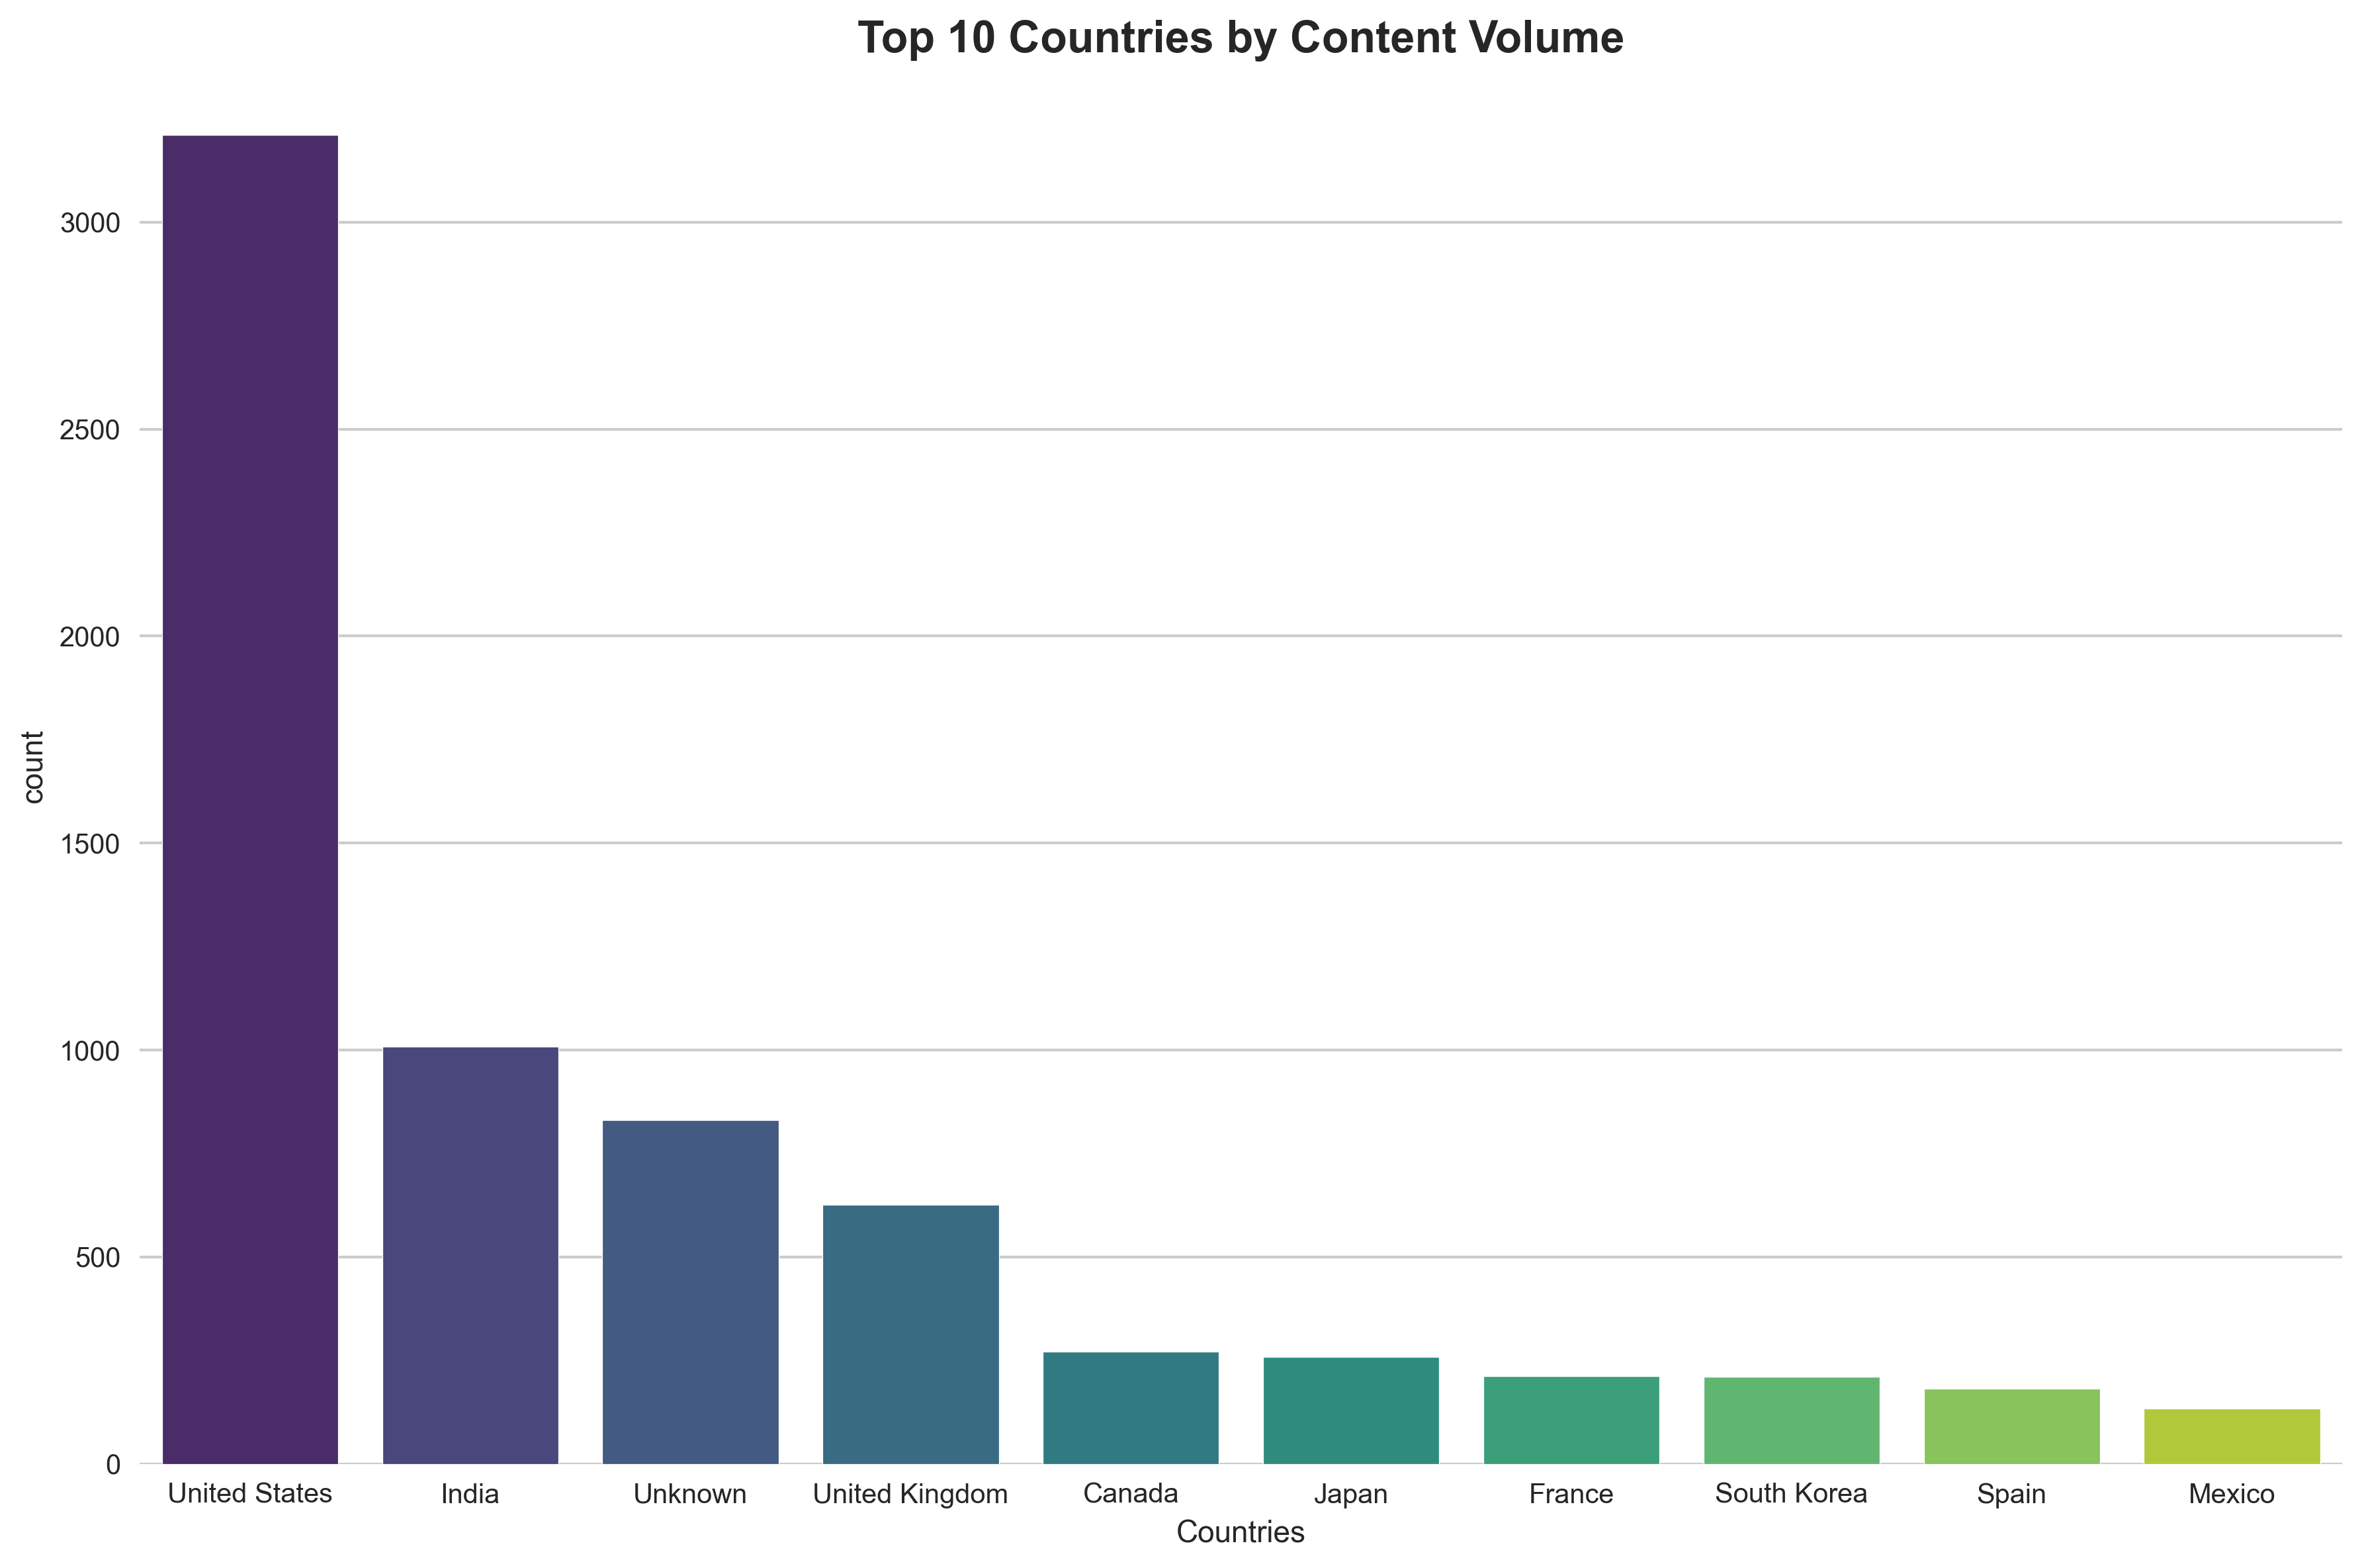

<Figure size 4200x2400 with 0 Axes>

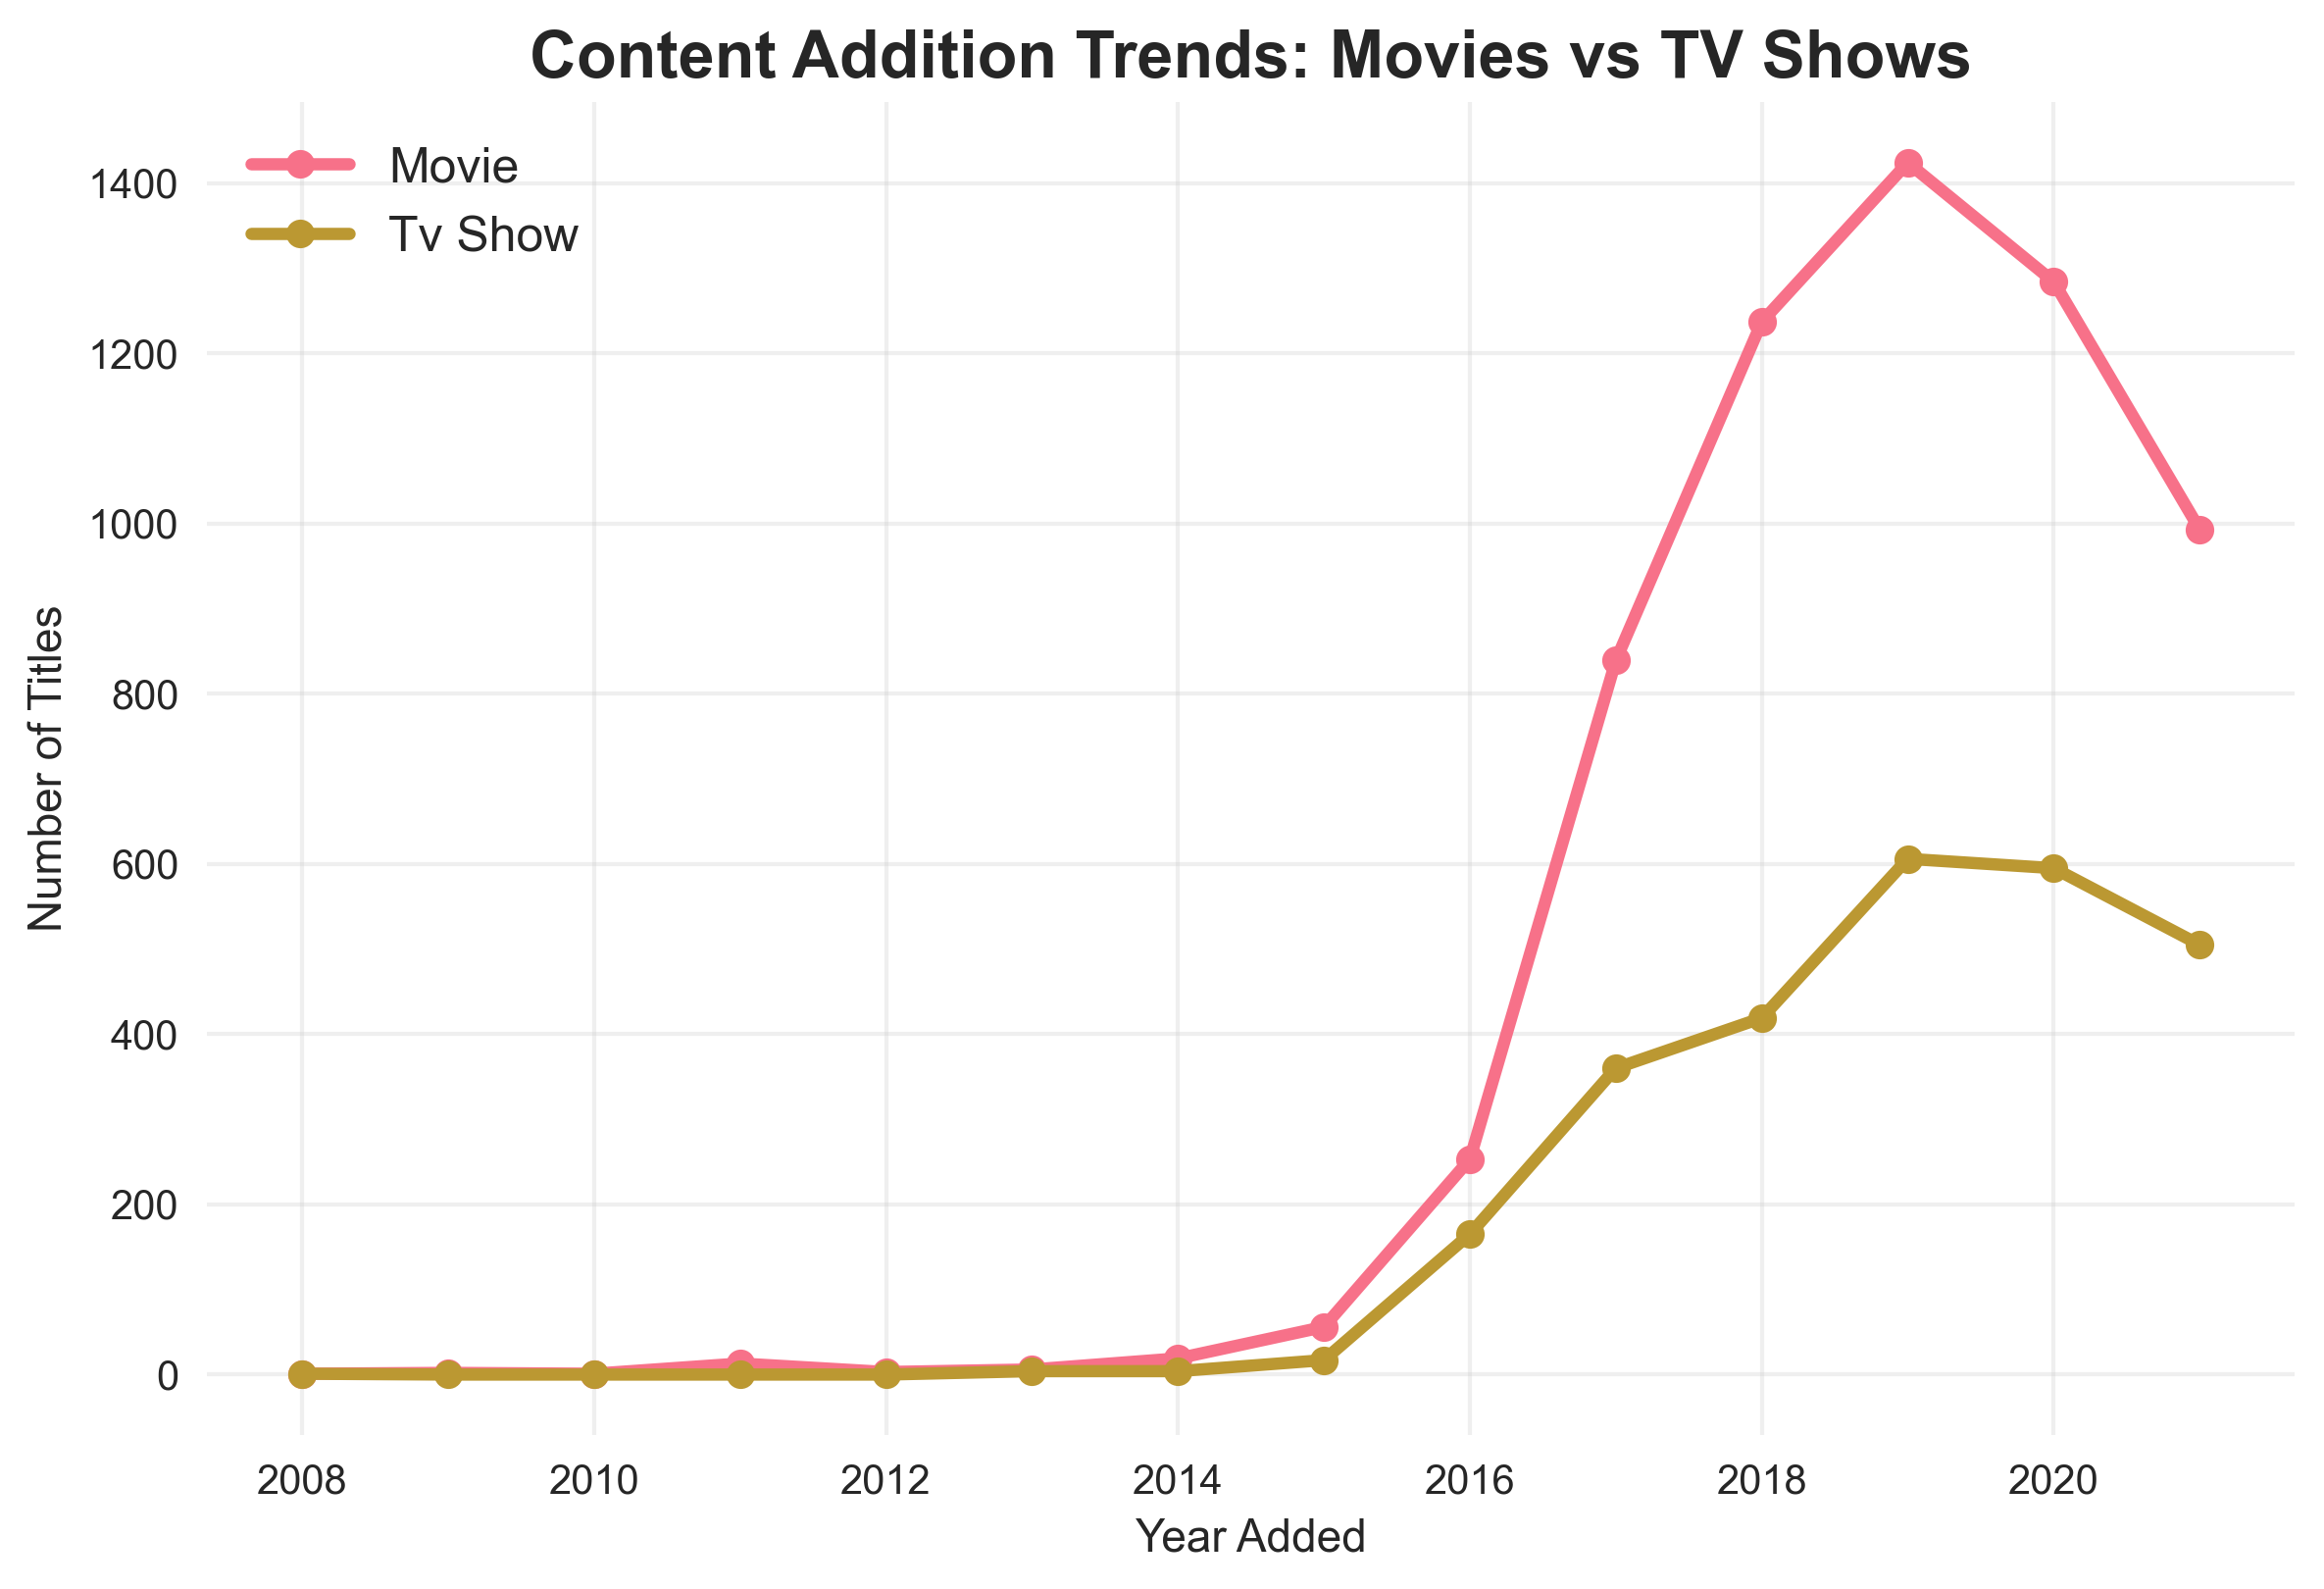

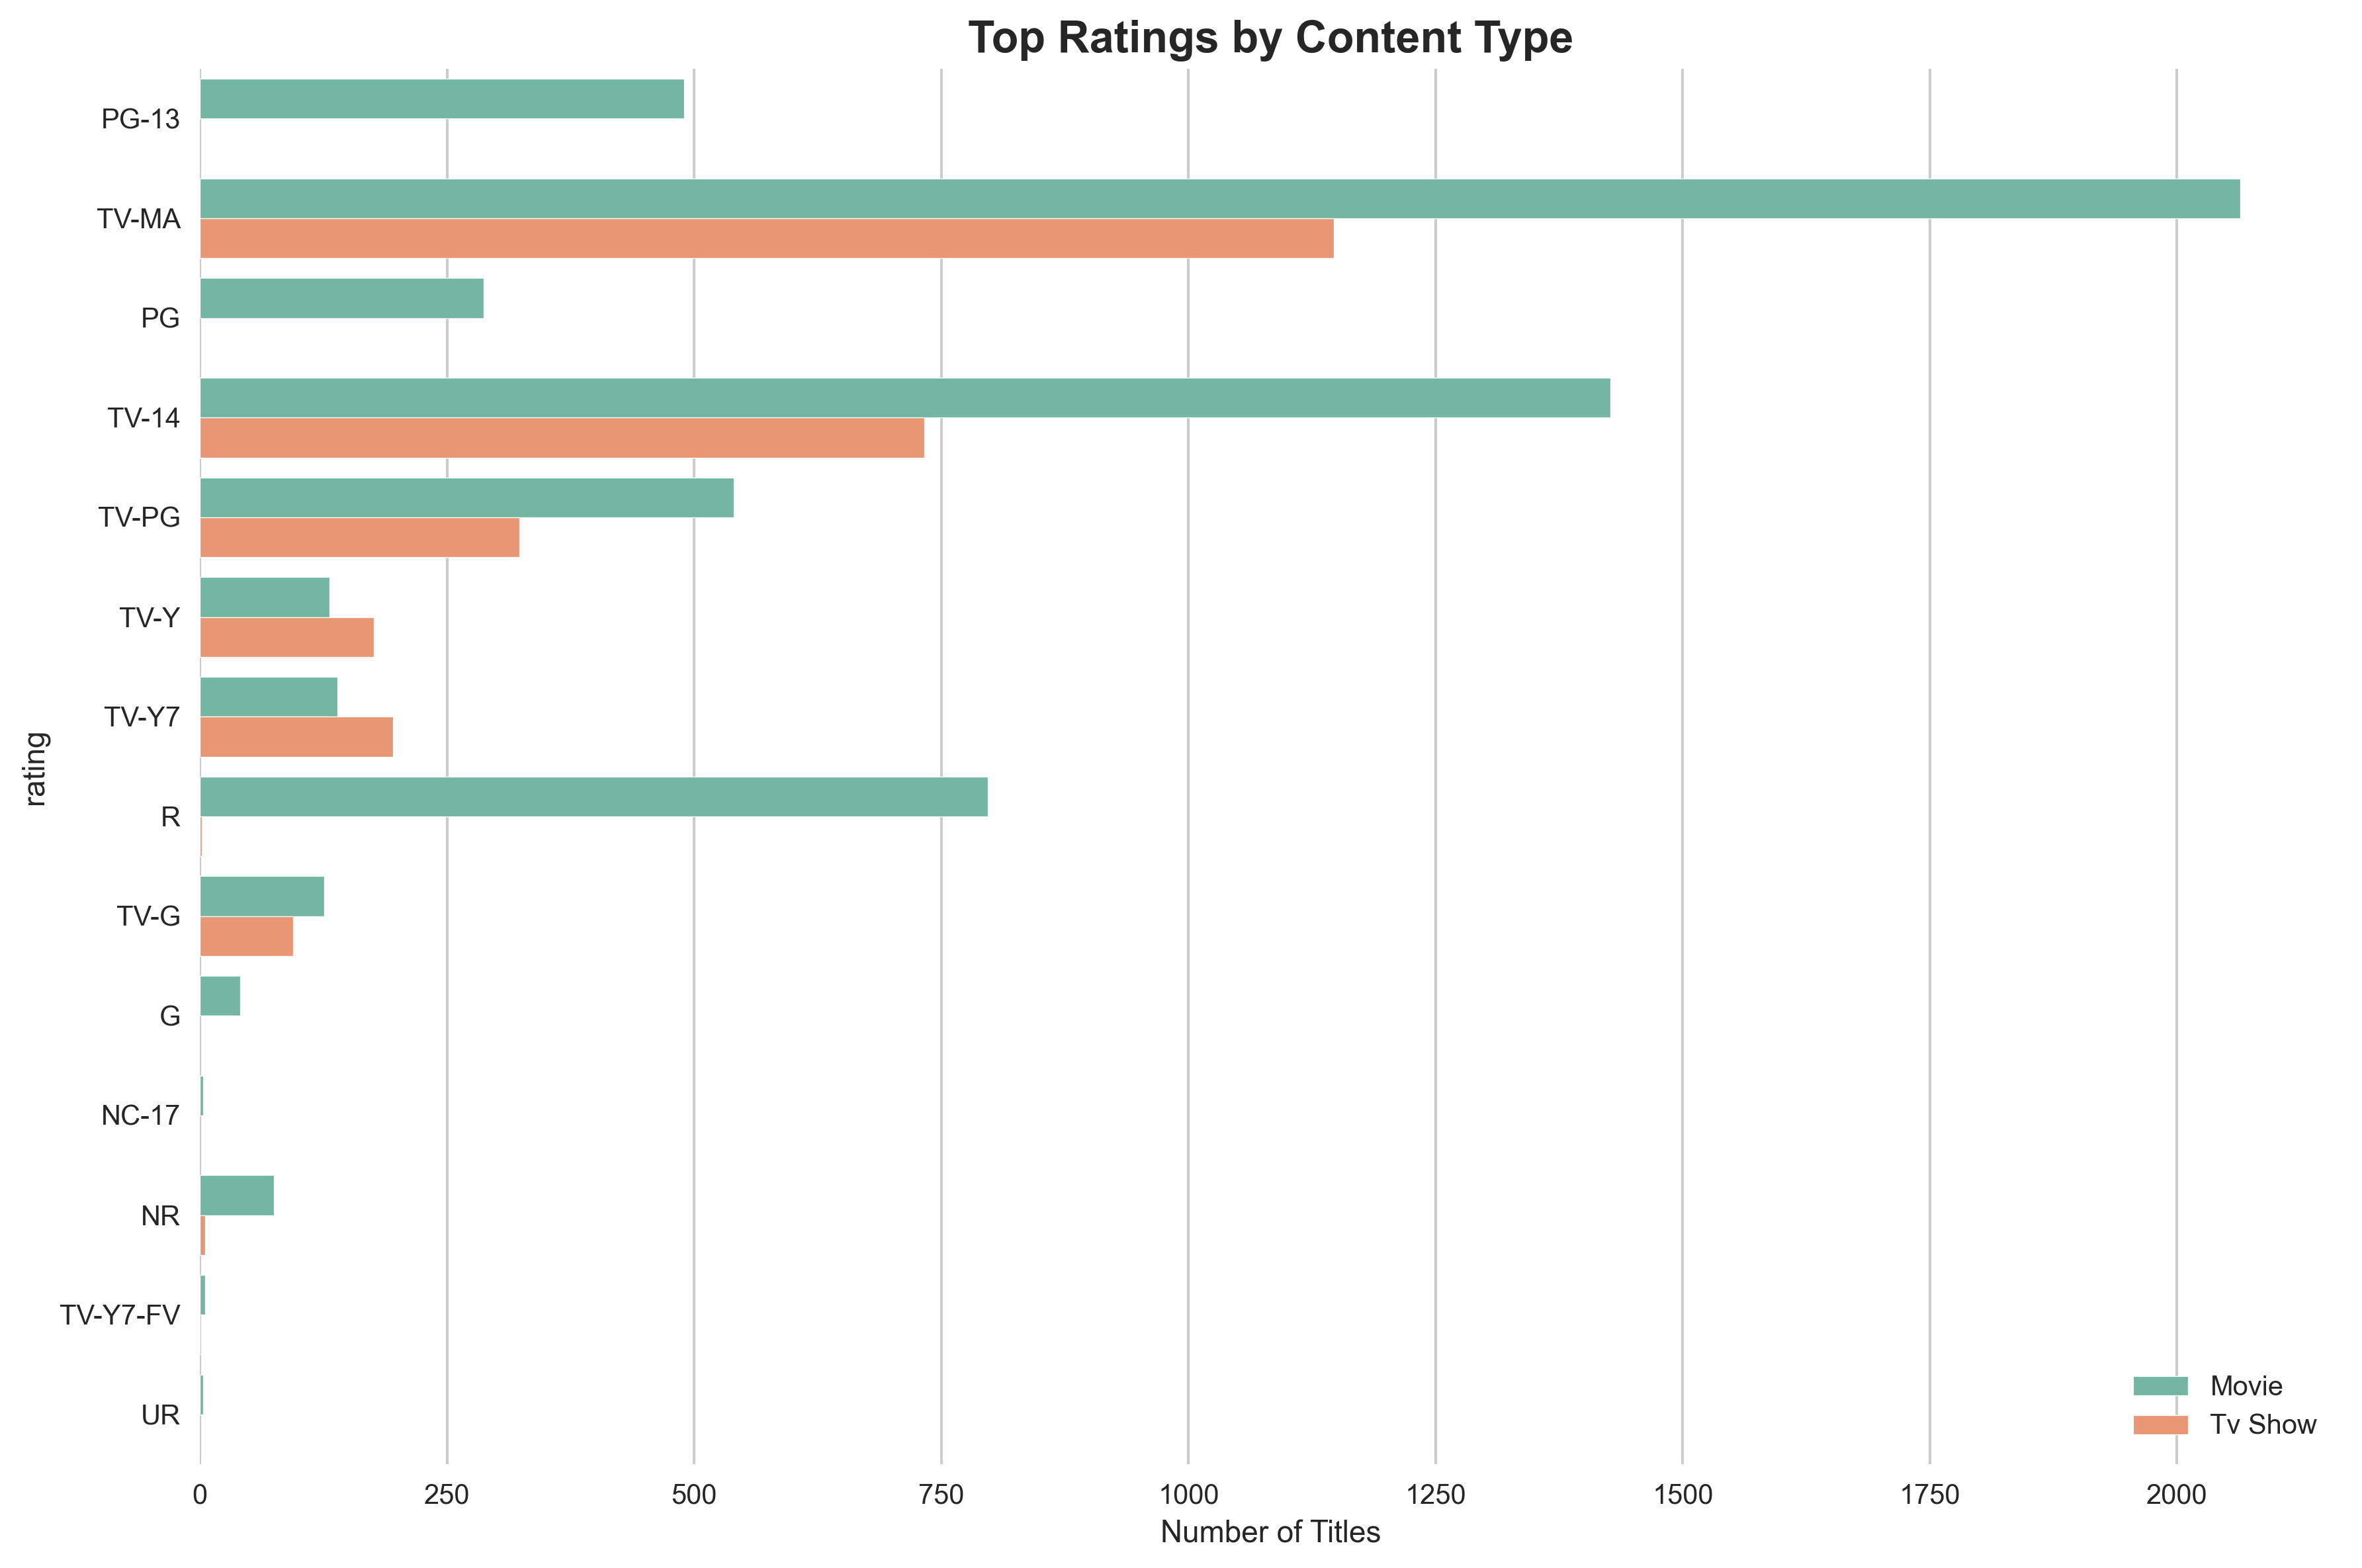

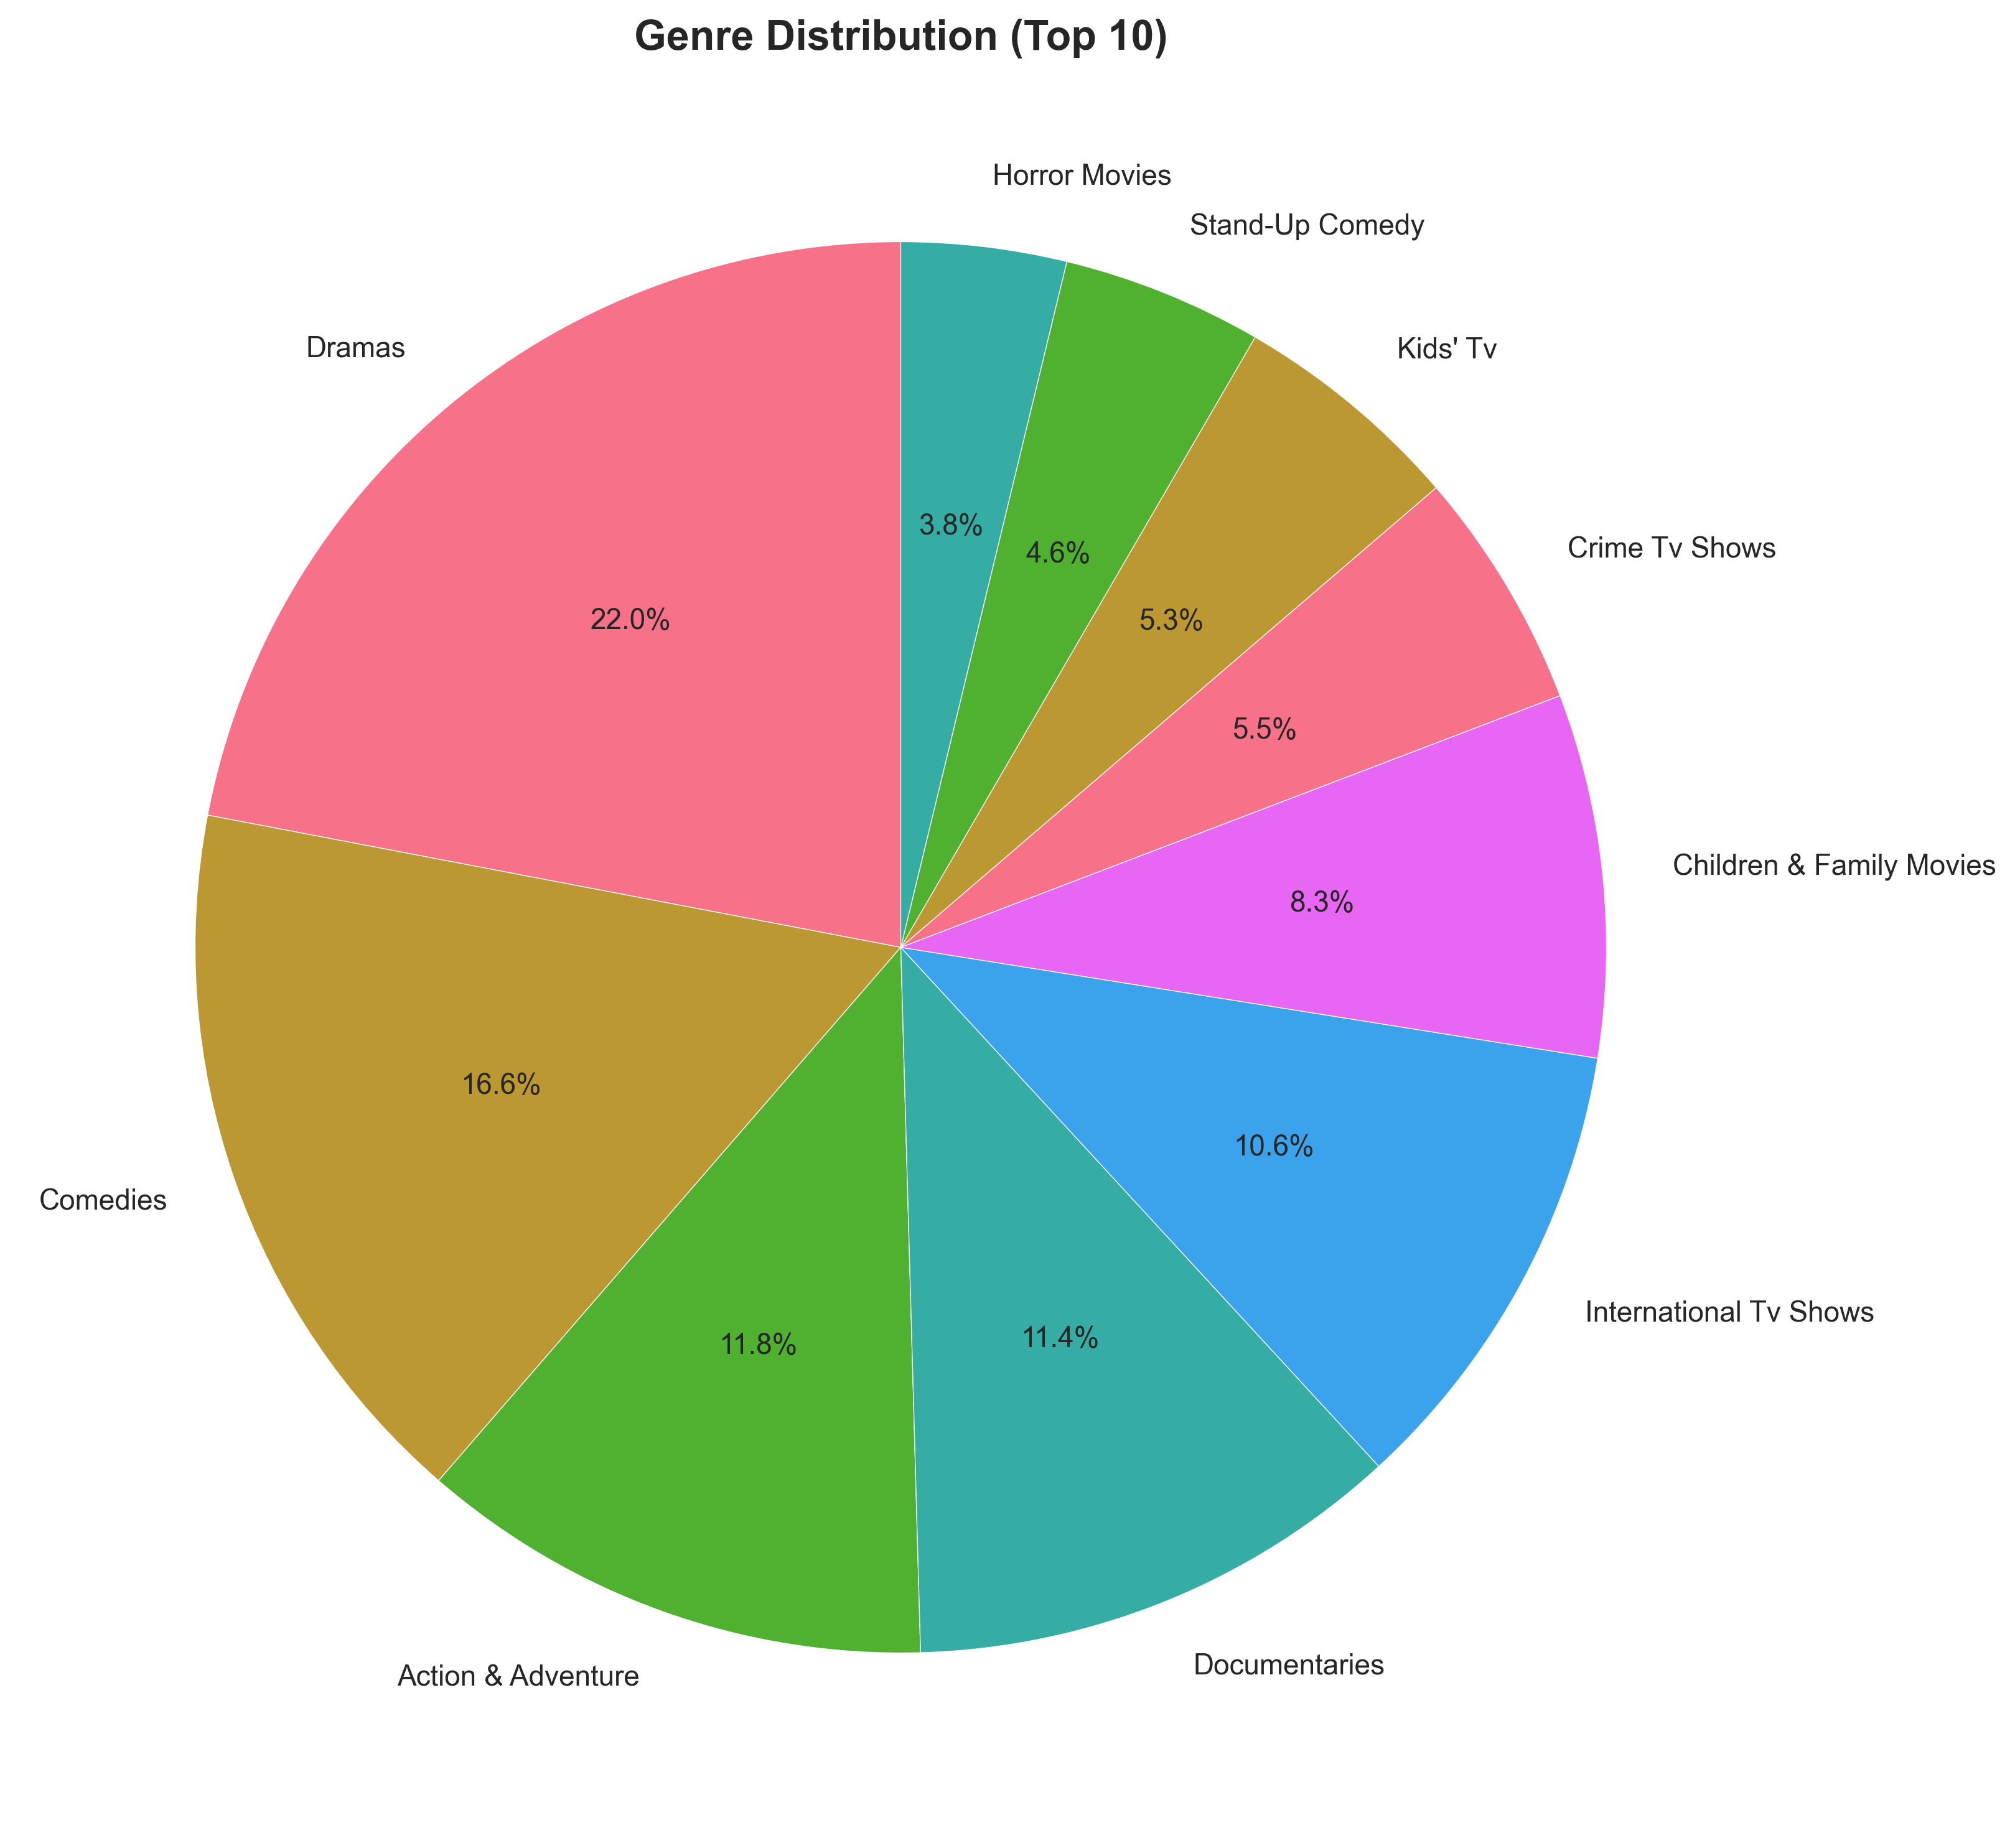

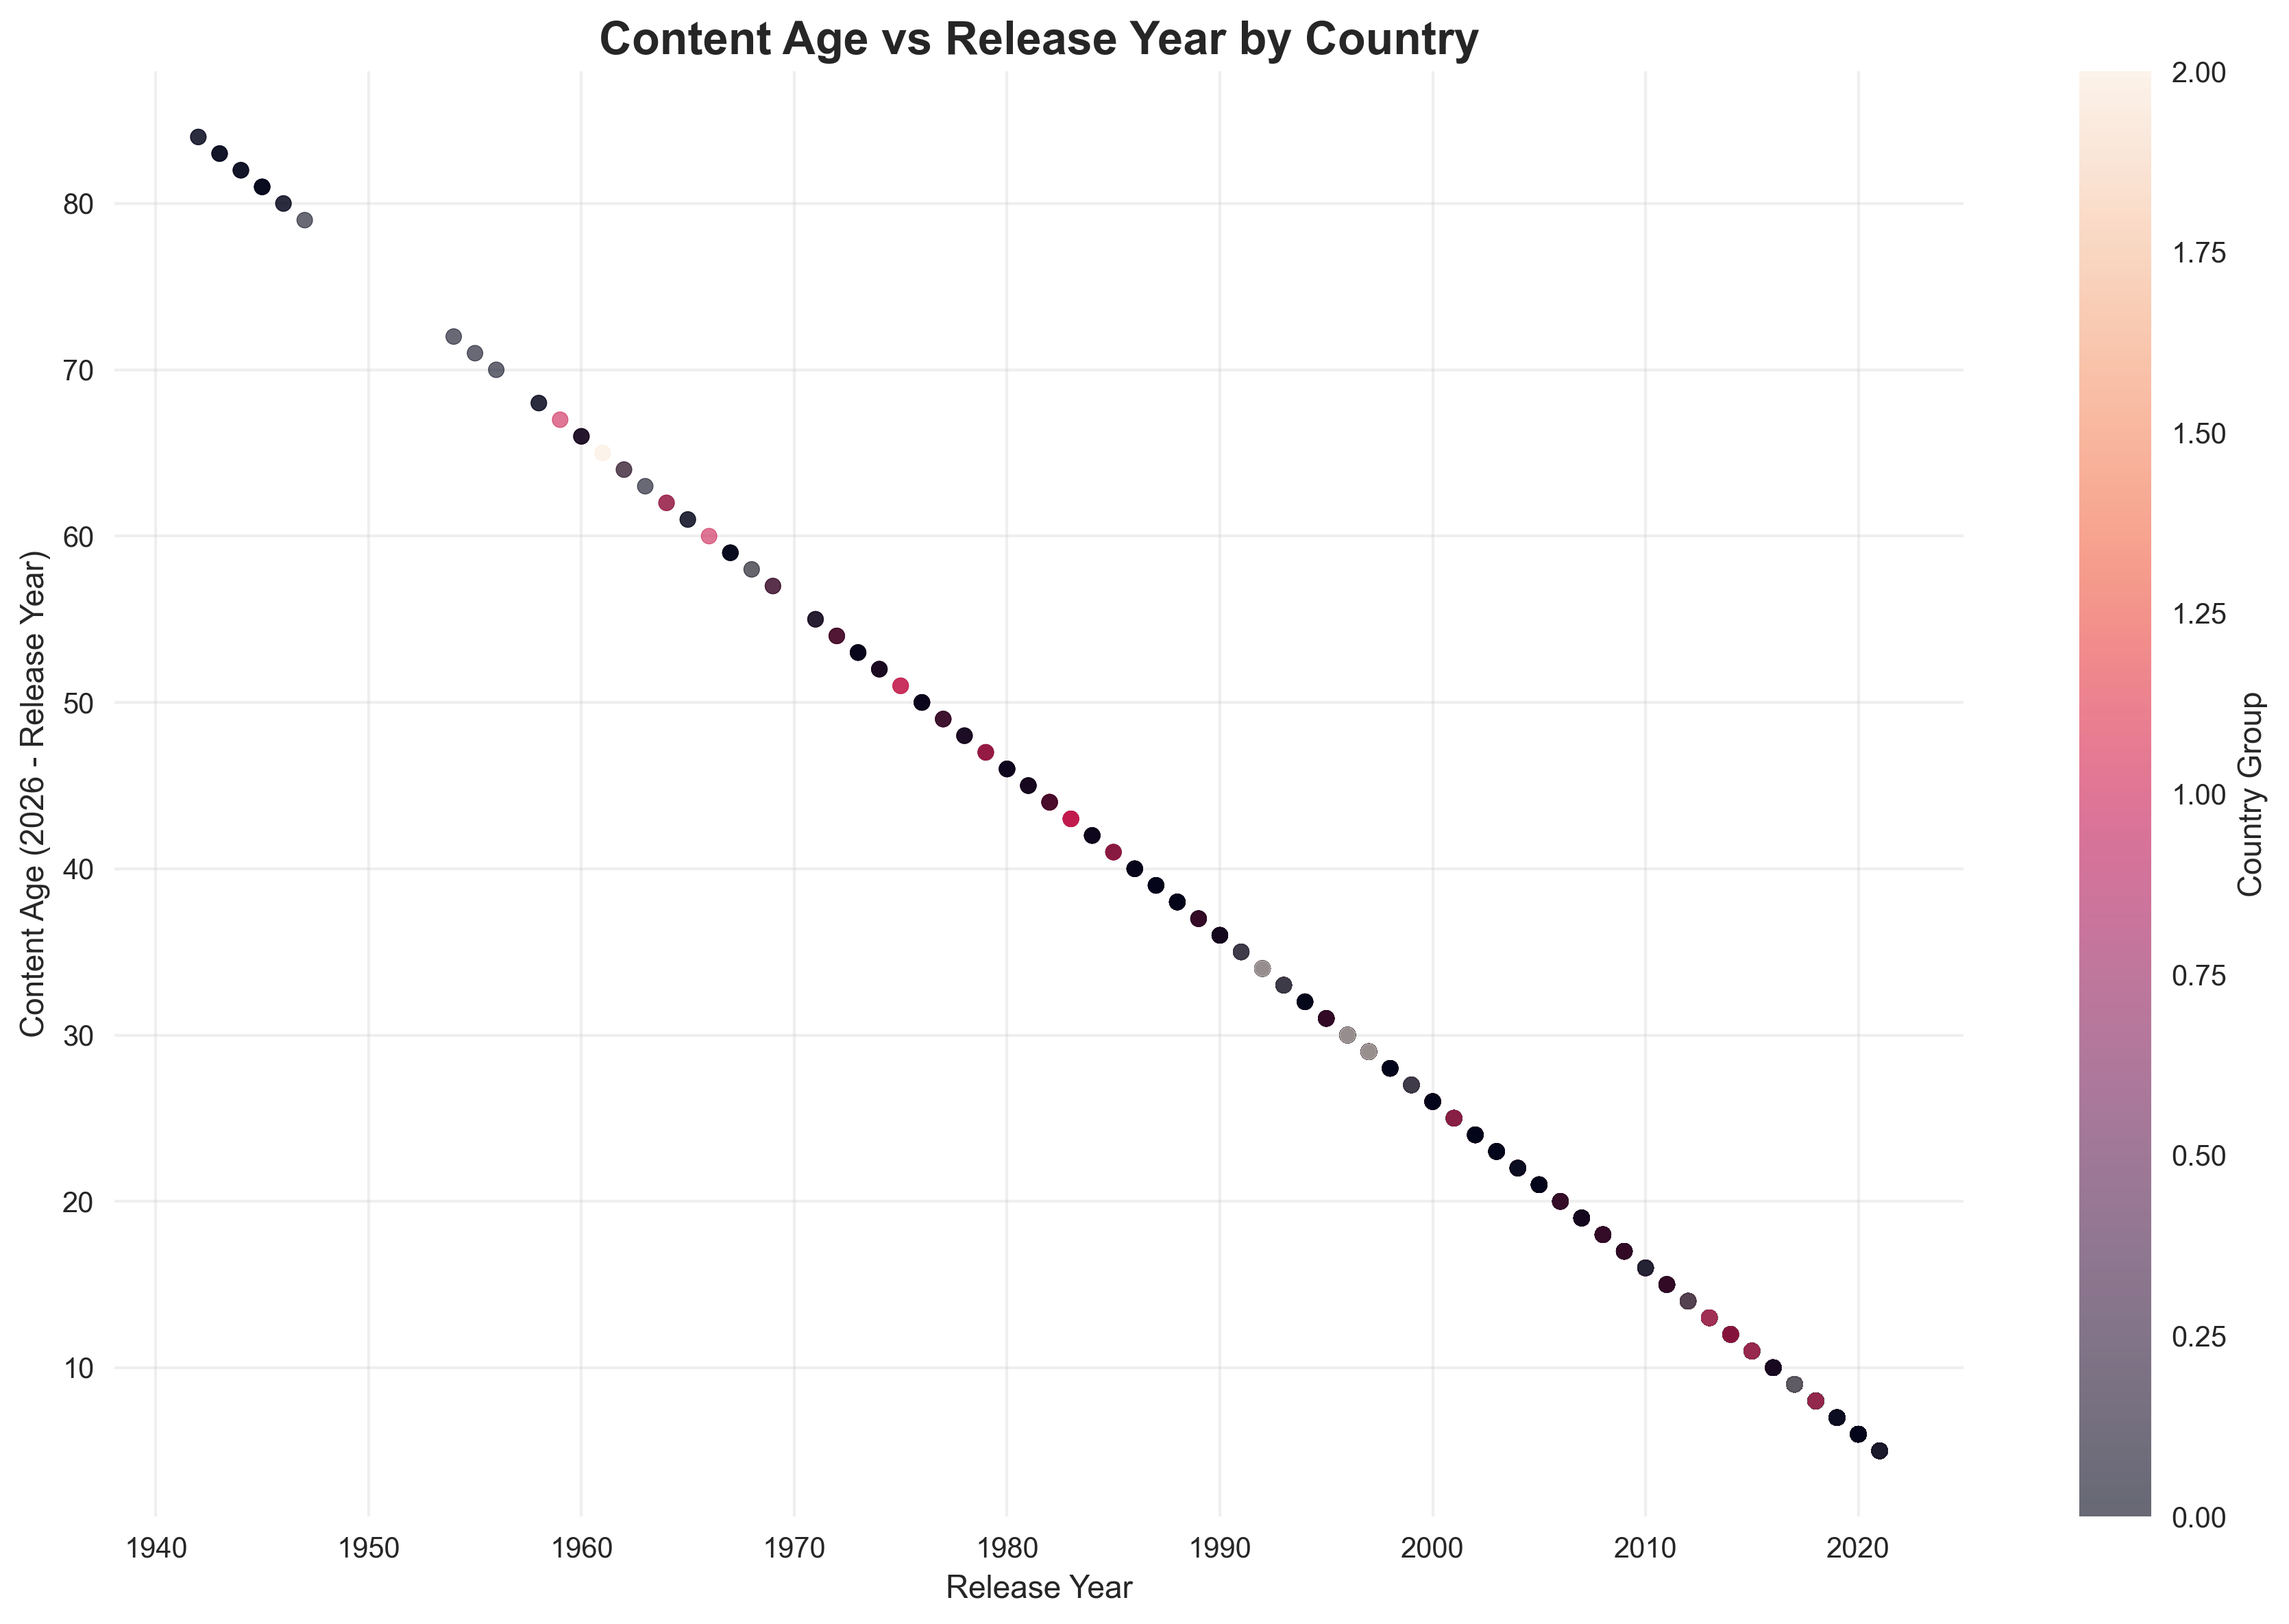

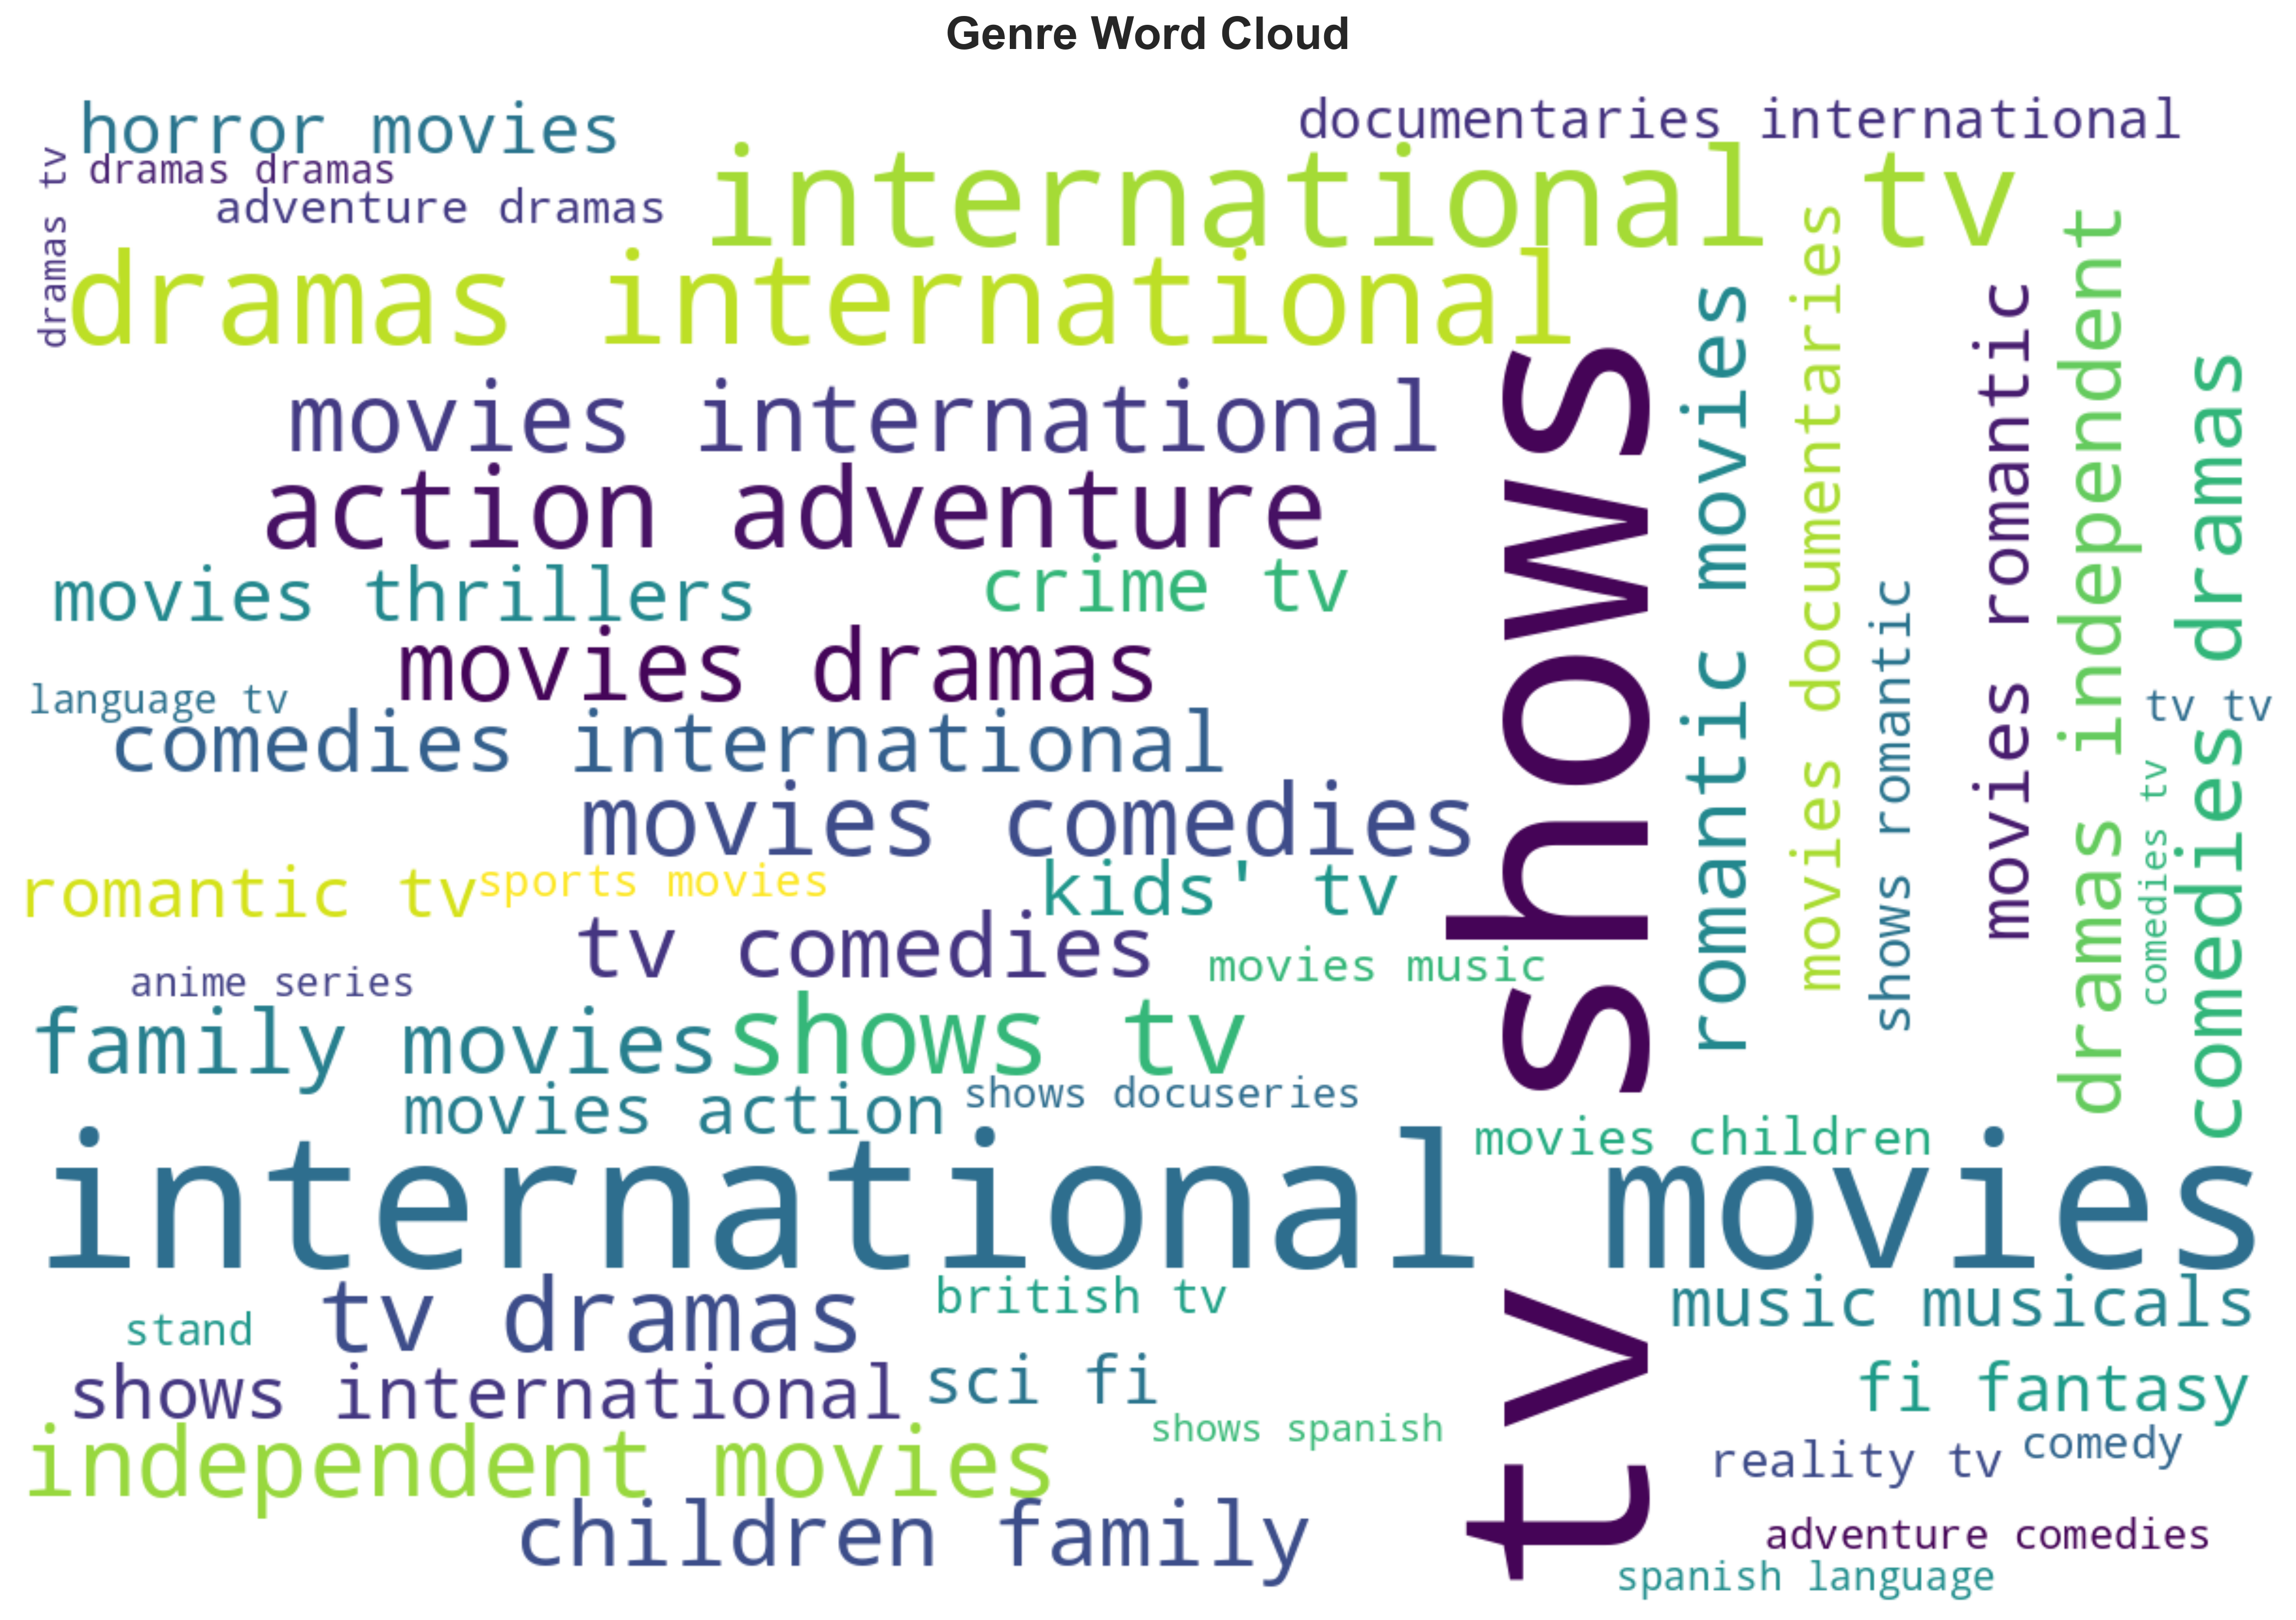

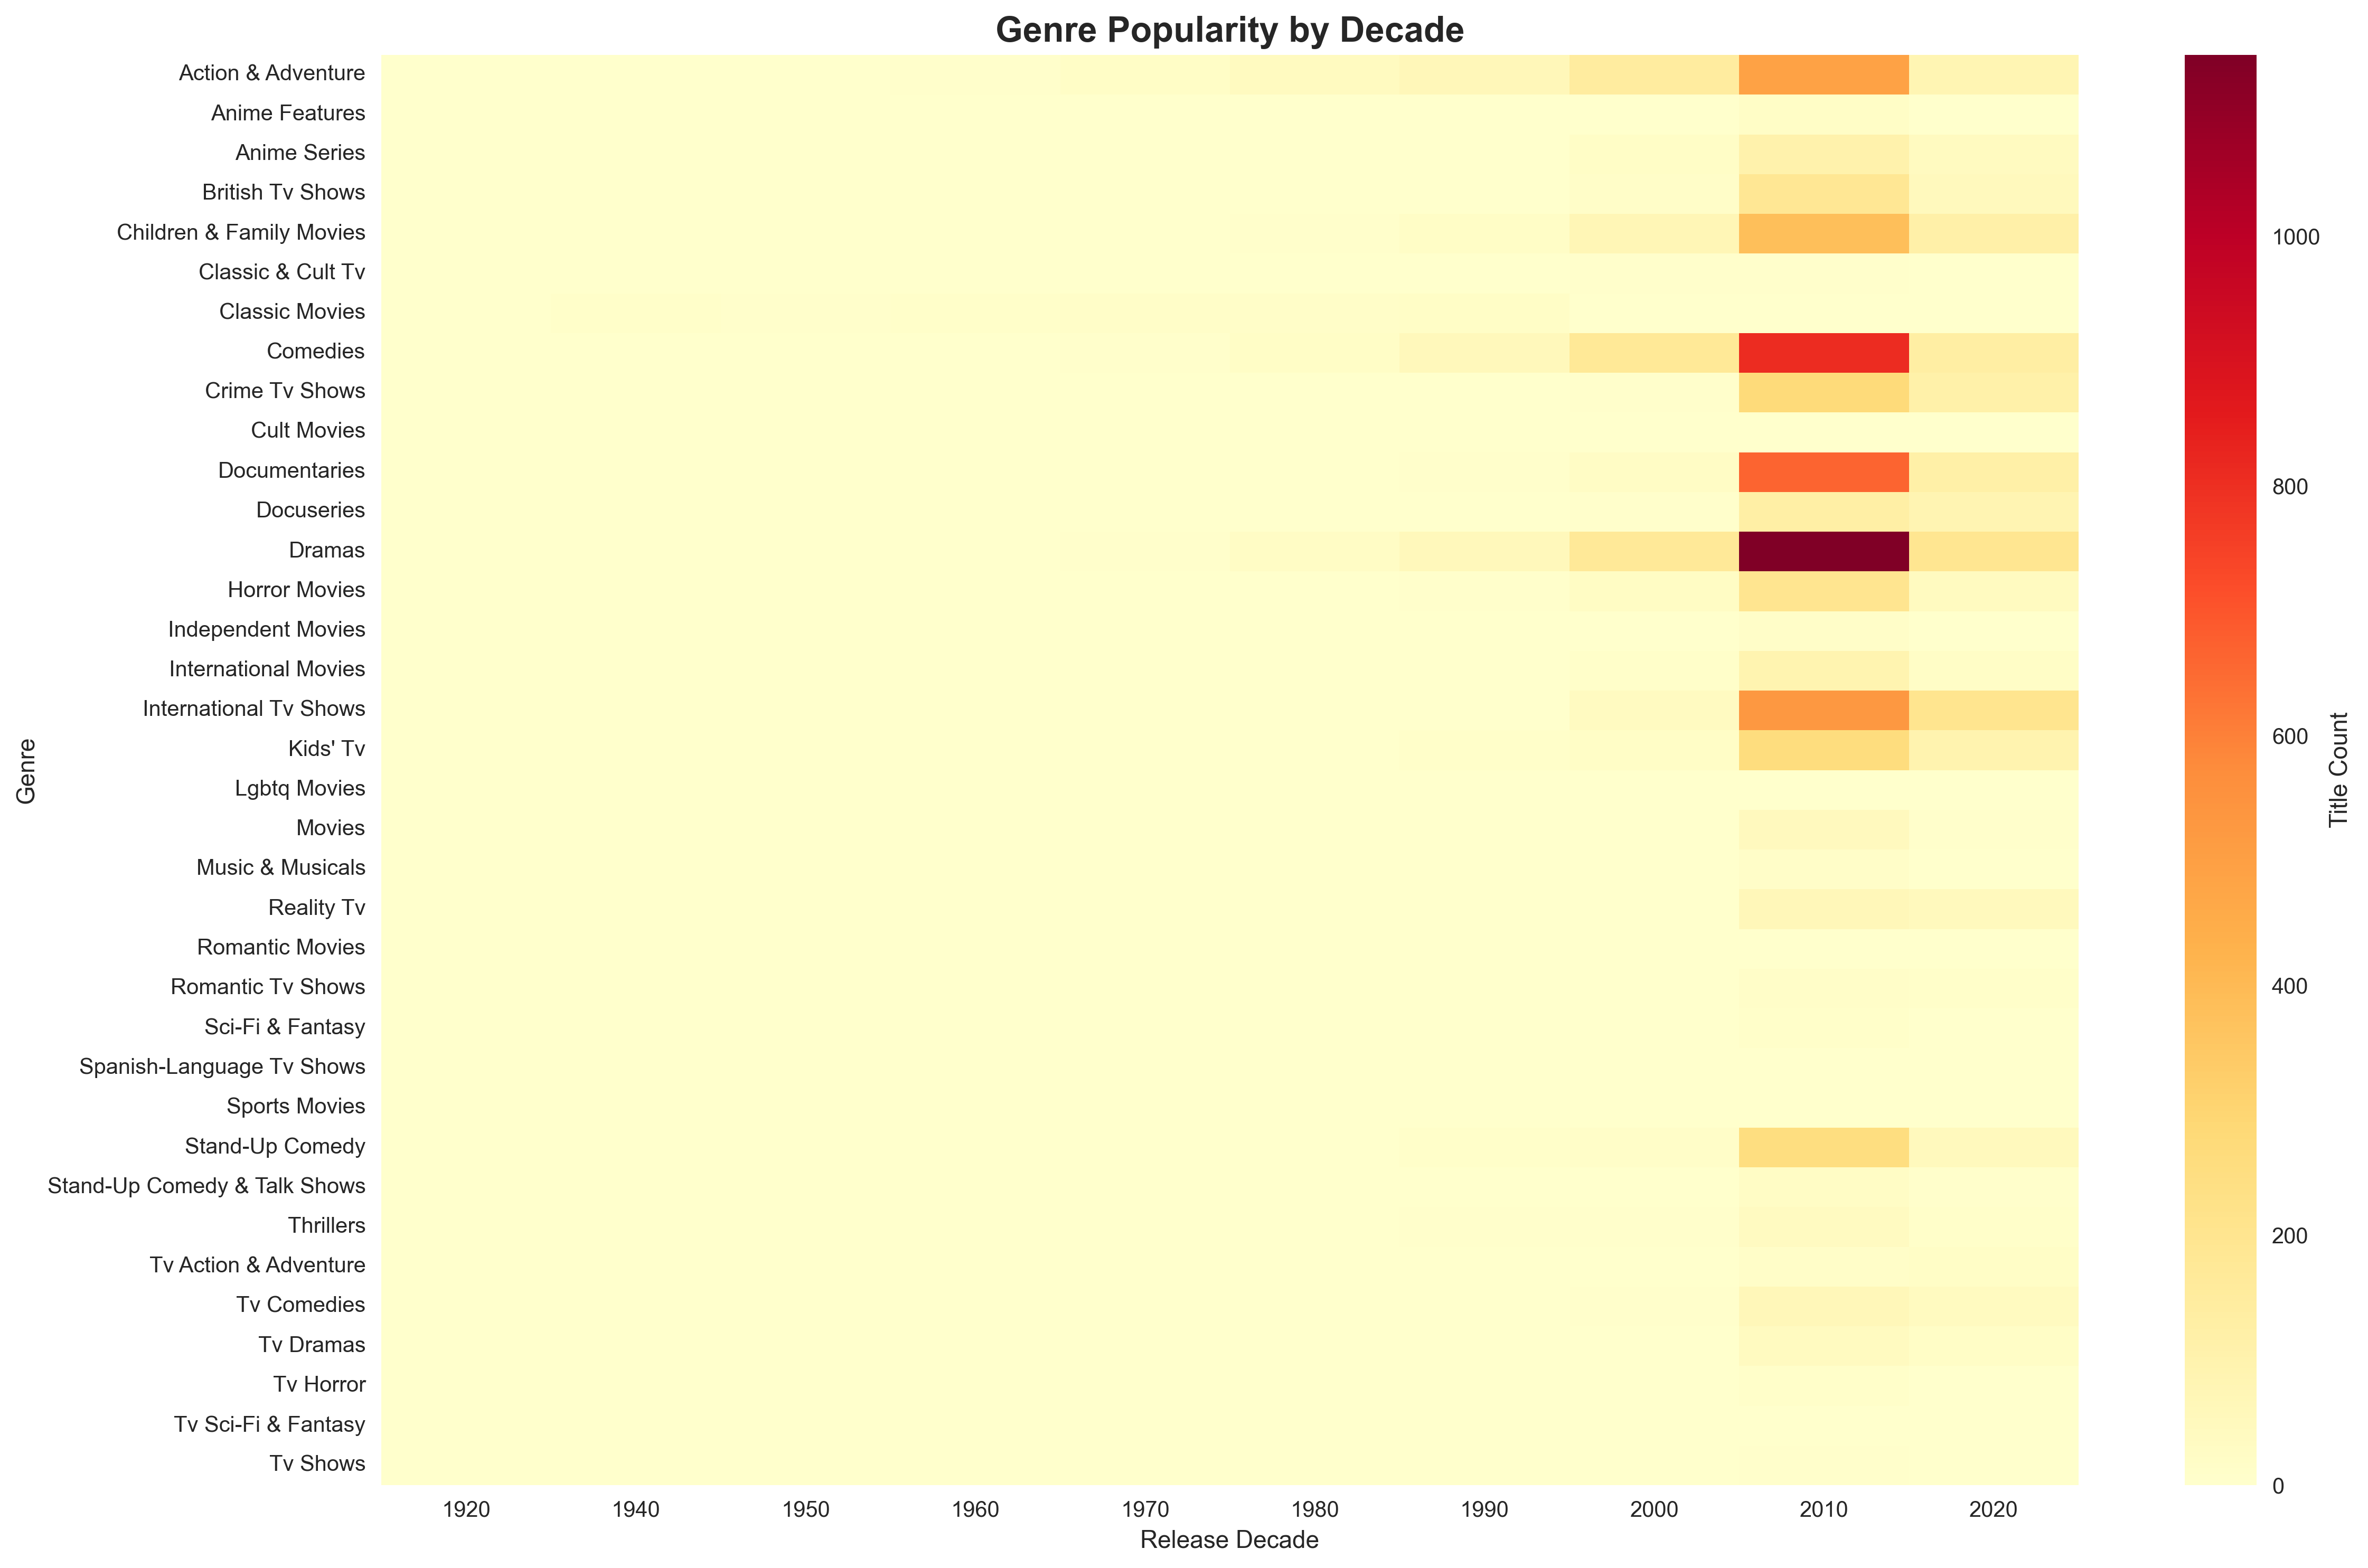

In [20]:
print("Creating publication-quality visualizations...")


# Set consistent styling
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# 1. Horizontal bar: Top 10 countries
plt.figure(figsize=(12, 8))
top10_countries = df_copy['country_group'].value_counts().head(10)
sns.barplot(data=top10_countries.reset_index() , x='country_group' , y='count' , palette='viridis')
plt.title('Top 10 Countries by Content Volume', fontsize=16, fontweight='bold')
plt.xlabel('Countries')
plt.tight_layout()
plt.savefig('images/01_top_countries.png', dpi=300, bbox_inches='tight')
plt.show()


# 2. Line plot: Content added per year (Movies vs TV)
plt.figure(figsize=(14,8))
yearly_content = df_copy.groupby(['year_added','content_type']).size().unstack(fill_value=0)
yearly_content.plot(kind='line' , linewidth = 3 , marker = 'o')
plt.title('Content Addition Trends: Movies vs TV Shows', fontsize=16, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/02_content_trends.png' , dpi = 300 , bbox_inches = 'tight')
plt.show()



#3. Rating distribution by content type
plt.figure(figsize=(12,8))
sns.countplot(data=df_copy , y='rating' , hue='content_type' , palette='Set2')
plt.title('Top Ratings by Content Type', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('images/03_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.legend(loc='lower right')
plt.show()



#4 Genre distribution pie chart

plt.figure(figsize=(12, 10))
top_genre_pie = df_copy['Primary_genre'].value_counts().head(10)
plt.pie(top_genre_pie.values , labels=top_genre_pie.index , autopct="%1.1f%%",
startangle=90, textprops={'fontsize': 11})
plt.title('Genre Distribution (Top 10)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05_genre_pie.png', dpi=300, bbox_inches='tight')
plt.show()


# 5. Scatter: Release year vs content age colored by country
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_copy['release_year'] , df_copy['content_age'], c = df_copy['country_group'].map({'United States': 0, 'India': 1, 'United Kingdom': 2, 'Other': 3}), alpha=0.6, s=30)
plt.xlabel('Release Year')
plt.ylabel('Content Age (2026 - Release Year)')
plt.title('Content Age vs Release Year by Country', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Country Group')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/06_release_vs_age.png', dpi=300, bbox_inches='tight')
plt.show()


# 6. Word cloud: Genres
plt.figure(figsize=(14, 10))
all_genres = ' '.join(df_copy['listed_in'].str.lower().str.replace(',',' '))
wordcloud = WordCloud(width=1200, height=800, background_color='white',
                     max_words=50, colormap='viridis').generate(all_genres)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Genre Word Cloud', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('images/07_genre_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()


# 7. Heatmap: Genre popularity by decade
df_copy['decade'] = (df_copy['release_year'] // 10 ) * 10
genre_decade = df_copy.groupby(['decade','Primary_genre']).size().unstack(fill_value=0)
plt.figure(figsize=(16, 10))
sns.heatmap(genre_decade.T, annot=False, cmap='YlOrRd',cbar_kws={'label': 'Title Count'})
plt.title('Genre Popularity by Decade', fontsize=16, fontweight='bold')
plt.xlabel('Release Decade')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('images/08_genre_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()




In [43]:
# 9-14. Interactive Plotly Dashboard (6 key metrics)

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# VS Code/Jupyter renderer
pio.renderers.default = 'browser'

# -------------------------------
# DATA PREPARATION
# -------------------------------

content_counts = df_copy['content_type'].value_counts()

rating_counts = df_copy['rating_category'].value_counts()

year_counts = df_copy['year_added'].value_counts().sort_index()

maturity_scores = df_copy['maturity_score'].dropna()

genre_counts = df_copy['genre_count'].dropna()

# -------------------------------
# DASHBOARD LAYOUT
# -------------------------------

fig = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=(
        'Content Type Distribution',
        'Top Countries',
        'Netflix Growth Over Time',
        'Audience Rating Categories',
        'Maturity Score Distribution',
        'Genre Diversity'
    ),
    specs=[
        [{"type": "pie"}, {"type": "bar"}],
        [{"type": "scatter"}, {"type": "bar"}],
        [{"type": "histogram"}, {"type": "box"}]
    ],
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

# -------------------------------
# 1. CONTENT TYPE DONUT CHART
# -------------------------------

fig.add_trace(
    go.Pie(
        labels=content_counts.index,
        values=content_counts.values,
        hole=0.55,
        textinfo='percent+label',
        marker=dict(colors=['#E50914', '#B81D24']),
        hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}<extra></extra>'
    ),
    row=1,
    col=1
)

# -------------------------------
# 2. TOP COUNTRIES BAR CHART
# -------------------------------

fig.add_trace(
    go.Bar(
        x=top_countries.index,
        y=top_countries.values,
        name='Countries',
        marker=dict(
            color=top_countries.values,
            colorscale='Reds'
        ),
        text=top_countries.values,
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>Titles: %{y}<extra></extra>'
    ),
    row=1,
    col=2
)

# -------------------------------
# 3. RELEASE YEAR TREND
# -------------------------------

fig.add_trace(
    go.Scatter(
        x=year_counts.index,
        y=year_counts.values,
        mode='lines+markers',
        line=dict(color='#E50914', width=4),
        marker=dict(size=8, color='white'),
        fill='tozeroy',
        fillcolor='rgba(229,9,20,0.15)',
        hovertemplate='<b>Year:</b> %{x}<br><b>Titles Added:</b> %{y}<extra></extra>'
    ),
    row=2,
    col=1
)

# -------------------------------
# 4. RATING CATEGORY BAR CHART
# -------------------------------

fig.add_trace(
    go.Bar(
        x=rating_counts.index,
        y=rating_counts.values,
        marker=dict(
            color=rating_counts.values,
            colorscale='Viridis'
        ),
        text=rating_counts.values,
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>Titles: %{y}<extra></extra>'
    ),
    row=2,
    col=2
)

# -------------------------------
# 5. MATURITY SCORE HISTOGRAM
# -------------------------------

fig.add_trace(
    go.Histogram(
        x=maturity_scores,
        nbinsx=10,
        marker=dict(color='#F5C518'),
        opacity=0.85,
        hovertemplate='Score Range: %{x}<br>Count: %{y}<extra></extra>'
    ),
    row=3,
    col=1
)

# -------------------------------
# 6. GENRE COUNT BOXPLOT
# -------------------------------

fig.add_trace(
    go.Box(
        y=genre_counts,
        marker_color='#00CC96',
        boxmean='sd',
        hovertemplate='Genre Count: %{y}<extra></extra>'
    ),
    row=3,
    col=2
)

# -------------------------------
# DASHBOARD STYLING
# -------------------------------

fig.update_layout(
    template='plotly_dark',
    height=1200,
    width=1500,
    title={
        'text': '🎬 Netflix Interactive Analytics Dashboard',
        'x': 0.5,
        'xanchor': 'center',
        'font': {
            'size': 28,
            'color': 'white'
        }
    },
    font=dict(
        family='Arial',
        size=12,
        color='white'
    ),
    paper_bgcolor='#111111',
    plot_bgcolor='#111111',
    margin=dict(t=100, l=60, r=60, b=60),
    showlegend=False
)

# -------------------------------
# AXIS CUSTOMIZATION
# -------------------------------

fig.update_xaxes(showgrid=False)
fig.update_yaxes(gridcolor='rgba(255,255,255,0.08)')

# -------------------------------
# SAVE + SHOW
# -------------------------------

fig.write_html('images/netflix_dashboard.html')
fig.show()



In [19]:
df_copy['year_added'].value_counts().sort_index()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1199
2018    1656
2019    2030
2020    1879
2021    1498
Name: count, dtype: int64

#### =============================================================================
#### 5. FINAL QUALITY METRICS & EXPORT
#### Production-ready dataset validation
#### =============================================================================

In [42]:
print("FINAL DATASET QUALITY REPORT")
print("="*50)

quality_metrics = {
    'Total Records' : df_copy.shape[0],
    'Features Created' : len([col for col in df_copy.columns if col not in df_copy.columns[:12]]),
    'Memory Usage' : f"{df_copy.memory_usage(deep=True).sum() / 1024**2:.2f}",
    'Missing Values' : df_copy.isnull().sum().sum(),
    'Duplicates Removed': 'Complete',
    'Date Parsing Success' : df_copy['date_added'].notna().mean()*100,
    'Duration Fixed'  : df_copy['duration_unit'].notna().mean()*100
}

for metric , value in quality_metrics.items():
    print(f"{metric:<20} : {value}")



# Final feature-engineered export
df_copy.to_csv('output/netflix_final_analysis.csv', index=False)
print("\nFinal dataset exported: output/netflix_final_analysis.csv")
print("\nPROJECT COMPLETE! Ready for GitHub portfolio.")
print(" Files created:")
print("   → output/netflix_cleaned.csv")
print("   → output/netflix_features.csv") 
print("   → output/netflix_final_analysis.csv")
print("   → images/ (visualizations)")
print("   → images/my_interactive_dashboard.html")

FINAL DATASET QUALITY REPORT
Total Records        : 8807
Features Created     : 19
Memory Usage         : 13.36
Missing Values       : 8903
Duplicates Removed   : Complete
Date Parsing Success : 100.0
Duration Fixed       : 100.0

Final dataset exported: output/netflix_final_analysis.csv

PROJECT COMPLETE! Ready for GitHub portfolio.
 Files created:
   → output/netflix_cleaned.csv
   → output/netflix_features.csv
   → output/netflix_final_analysis.csv
   → images/ (visualizations)
   → images/my_interactive_dashboard.html
